# 🎯 Preprocessing Citra & Klasifikasi Emosi Wajah — FER2013
**Tugas Kelompok 1 Kelas A — GLCM + Logistic Regression**

---

### 📋 Deskripsi Notebook
Notebook ini mencakup **seluruh pipeline** dari preprocessing hingga evaluasi dan analisis mendalam:

| Tahap | Konten |
|-------|--------|
| **0** | Requirements & Instalasi |
| **1** | Import Library & Konfigurasi |
| **2** | Load & Verifikasi Dataset |
| **3** | Preprocessing Citra (Grayscale → Resize → Gaussian → Normalisasi) |
| **4** | Ekstraksi Fitur GLCM |
| **5** | Eksperimen: Level Kuantisasi & Agregasi |
| **6** | Model Logistic Regression |
| **7** | Evaluasi (Accuracy, F1, Confusion Matrix) |
| **8** | Analisis Wajib (5 pertanyaan) |
| **9** | Error Analysis + Visualisasi Gambar Salah Klasifikasi |
| **10** | Ringkasan & Kesimpulan |

> 📌 **Dataset**: [FER2013 — Kaggle](https://www.kaggle.com/datasets/msambare/fer2013)  
> Letakkan dataset di folder `dataset/` dengan struktur `dataset/train/<kelas>/` dan `dataset/test/<kelas>/`

---
## 📦 0. Requirements — Instalasi Library

Jalankan cell berikut **satu kali** sebelum memulai. Pastikan menggunakan Python ≥ 3.8.

**Library yang dibutuhkan:**

| Library | Versi Min | Kegunaan |
|---------|-----------|----------|
| `opencv-python` | 4.5+ | Load & proses gambar |
| `numpy` | 1.21+ | Operasi array |
| `matplotlib` | 3.4+ | Visualisasi |
| `scikit-image` | 0.18+ | Ekstraksi GLCM |
| `scikit-learn` | 1.0+ | Logistic Regression & evaluasi |
| `scipy` | 1.7+ | Gaussian filter |
| `tqdm` | 4.60+ | Progress bar |
| `Pillow` | 8.0+ | Manipulasi gambar |
| `seaborn` | 0.11+ | Confusion matrix heatmap |
| `pandas` | 1.3+ | Tabel hasil eksperimen |

---
## 📚 1. Import Library & Konfigurasi

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import warnings

from scipy.ndimage import gaussian_filter
from skimage.feature import graycomatrix, graycoprops
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.notebook import tqdm
from PIL import Image

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Konfigurasi Global ────────────────────────────────────────
SOURCE_DIR      = 'dataset'              # folder dataset asli
OUTPUT_DIR      = 'fer2013_preprocessed' # folder output preprocessing
CLASSES         = ['angry', 'happy', 'sad', 'surprise']
IMG_SIZE        = (48, 48)
GAUSSIAN_SIGMA  = 1.0

# Parameter GLCM
GLCM_DISTANCES  = [1]                   # jarak d=1
GLCM_ANGLES     = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 0°, 45°, 90°, 135°
GLCM_PROPS      = ['contrast', 'homogeneity', 'energy', 'correlation']

# Warna per kelas untuk visualisasi
CLASS_COLORS = {
    'angry'   : '#E74C3C',
    'happy'   : '#F39C12',
    'sad'     : '#3498DB',
    'surprise': '#9B59B6'
}

print('✅ Library berhasil diimport')
print(f'   Source       : {SOURCE_DIR}')
print(f'   Output       : {OUTPUT_DIR}')
print(f'   Kelas        : {CLASSES}')
print(f'   Ukuran gambar: {IMG_SIZE}')
print(f'   GLCM angles  : 0°, 45°, 90°, 135°')
print(f'   GLCM props   : {GLCM_PROPS}')

✅ Library berhasil diimport
   Source       : dataset
   Output       : fer2013_preprocessed
   Kelas        : ['angry', 'happy', 'sad', 'surprise']
   Ukuran gambar: (48, 48)
   GLCM angles  : 0°, 45°, 90°, 135°
   GLCM props   : ['contrast', 'homogeneity', 'energy', 'correlation']


---
## 📂 2. Load & Verifikasi Dataset
Cek jumlah file per kelas dan pastikan distribusi seimbang.

In [2]:
# ── Hitung jumlah file per split & kelas ─────────────────────
dataset_info = {}

print('='*55)
print(f'  {"SPLIT":<8} {"KELAS":<12} {"JUMLAH FILE":>12}')
print('='*55)

for split in ['train', 'test']:
    dataset_info[split] = {}
    split_total = 0
    for cls in CLASSES:
        path = os.path.join(SOURCE_DIR, split, cls)
        if os.path.exists(path):
            n = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        else:
            n = 0
            print(f'  ⚠️  Folder tidak ditemukan: {path}')
        dataset_info[split][cls] = n
        split_total += n
        print(f'  {split.upper():<8} {cls:<12} {n:>12,}')
    print(f'  {"-"*43}')
    print(f'  {"":8} {"SUBTOTAL":<12} {split_total:>12,}')
    print()

grand_total = sum(sum(v.values()) for v in dataset_info.values())
print(f'  GRAND TOTAL : {grand_total:,} file')
print('='*55)

  SPLIT    KELAS         JUMLAH FILE
  TRAIN    angry               3,100
  TRAIN    happy               3,100
  TRAIN    sad                 3,100
  TRAIN    surprise            3,100
  -------------------------------------------
           SUBTOTAL           12,400

  TEST     angry                 775
  TEST     happy                 775
  TEST     sad                   775
  TEST     surprise              775
  -------------------------------------------
           SUBTOTAL            3,100

  GRAND TOTAL : 15,500 file


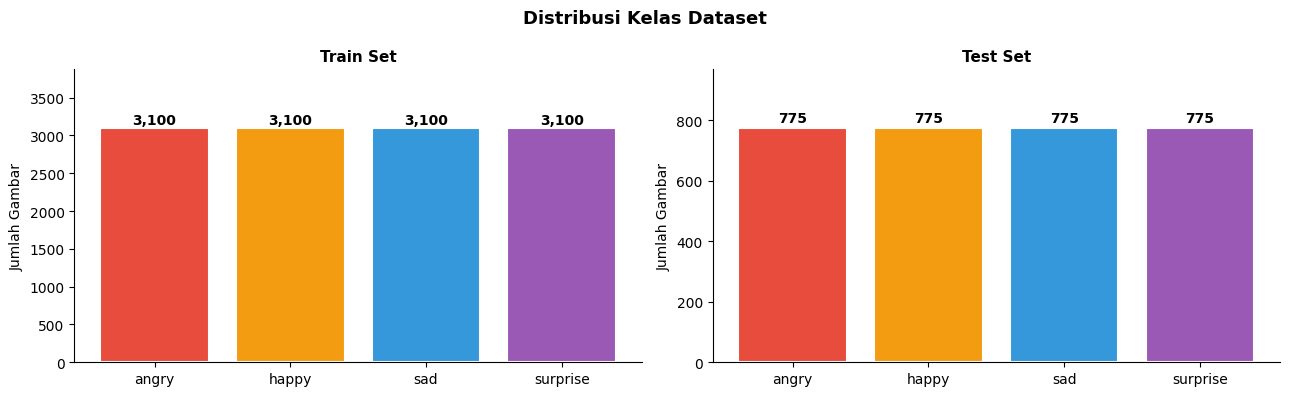

📊 Distribusi kelas divisualisasikan.


In [3]:
# ── Visualisasi distribusi kelas ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Kelas Dataset', fontsize=13, fontweight='bold')

for idx, split in enumerate(['train', 'test']):
    counts = [dataset_info[split][cls] for cls in CLASSES]
    colors = [CLASS_COLORS[cls] for cls in CLASSES]
    bars = axes[idx].bar(CLASSES, counts, color=colors, edgecolor='white', linewidth=1.5)
    axes[idx].set_title(f'{split.capitalize()} Set', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Jumlah Gambar')
    axes[idx].set_ylim(0, max(counts) * 1.25 if max(counts) > 0 else 10)
    axes[idx].spines[['top','right']].set_visible(False)
    for bar, count in zip(bars, counts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                       f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribusi_kelas.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Distribusi kelas divisualisasikan.')

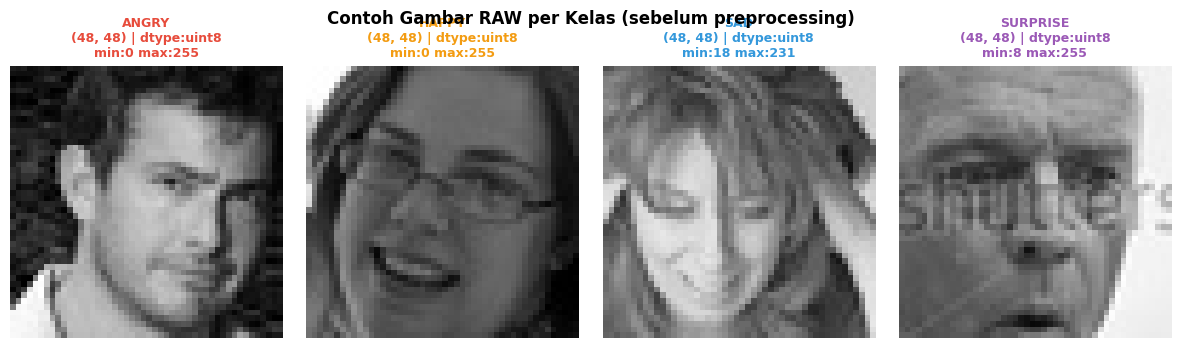

🖼️  Sampel gambar RAW ditampilkan.


In [4]:
# ── Tampilkan 1 sampel gambar per kelas (RAW) ─────────────────
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
fig.suptitle('Contoh Gambar RAW per Kelas (sebelum preprocessing)', fontsize=12, fontweight='bold')

sample_images = {}

for i, cls in enumerate(CLASSES):
    img_dir  = os.path.join(SOURCE_DIR, 'train', cls)
    files    = sorted([f for f in os.listdir(img_dir)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    fname    = files[0]
    img_path = os.path.join(img_dir, fname)
    img      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    sample_images[cls] = {'path': img_path, 'fname': fname, 'raw': img.copy()}

    axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(
        f'{cls.upper()}\n{img.shape} | dtype:{img.dtype}\nmin:{img.min()} max:{img.max()}',
        fontsize=9, color=CLASS_COLORS[cls], fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('02_sampel_raw.png', dpi=120, bbox_inches='tight')
plt.show()
print('🖼️  Sampel gambar RAW ditampilkan.')

---
## 🔧 3. Preprocessing Citra

Pipeline preprocessing terdiri dari 5 langkah:
1. **Grayscale** — FER2013 sudah grayscale, tapi kita verifikasi dan konversi otomatis jika perlu  
2. **Resize 48×48** — memastikan semua gambar berukuran seragam  
3. **Gaussian Filter (σ=1.0)** — mengurangi noise, GLCM sensitif terhadap noise antar piksel tetangga  
4. **Normalisasi 0–1** — agar model lebih stabil secara numerik  
5. **Simpan** — format `.png` (uint8) untuk visualisasi dan `.npy` (float32) untuk pipeline GLCM

In [5]:
# ── Langkah 1: Verifikasi Grayscale ──────────────────────────
print('Pemeriksaan channel gambar per kelas:')
print('-'*55)

for cls in CLASSES:
    img_dir = os.path.join(SOURCE_DIR, 'train', cls)
    files   = sorted([f for f in os.listdir(img_dir)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    img_raw = cv2.imread(os.path.join(img_dir, files[0]))
    shape   = img_raw.shape

    if len(shape) == 2:
        status = '✅ Sudah Grayscale (2D)'
    elif len(shape) == 3 and shape[2] == 1:
        status = '✅ Grayscale (3D, 1 channel)'
    elif len(shape) == 3 and shape[2] == 3:
        status = '⚠️  BGR — akan dikonversi ke Grayscale'
    else:
        status = f'❓ Channel tidak dikenal: {shape}'

    print(f'  [{cls.upper():<8}] shape={shape}  →  {status}')

print()
print('ℹ️  Fungsi preprocess_image() menangani konversi otomatis.')

Pemeriksaan channel gambar per kelas:
-------------------------------------------------------
  [ANGRY   ] shape=(48, 48, 3)  →  ⚠️  BGR — akan dikonversi ke Grayscale
  [HAPPY   ] shape=(48, 48, 3)  →  ⚠️  BGR — akan dikonversi ke Grayscale
  [SAD     ] shape=(48, 48, 3)  →  ⚠️  BGR — akan dikonversi ke Grayscale
  [SURPRISE] shape=(48, 48, 3)  →  ⚠️  BGR — akan dikonversi ke Grayscale

ℹ️  Fungsi preprocess_image() menangani konversi otomatis.


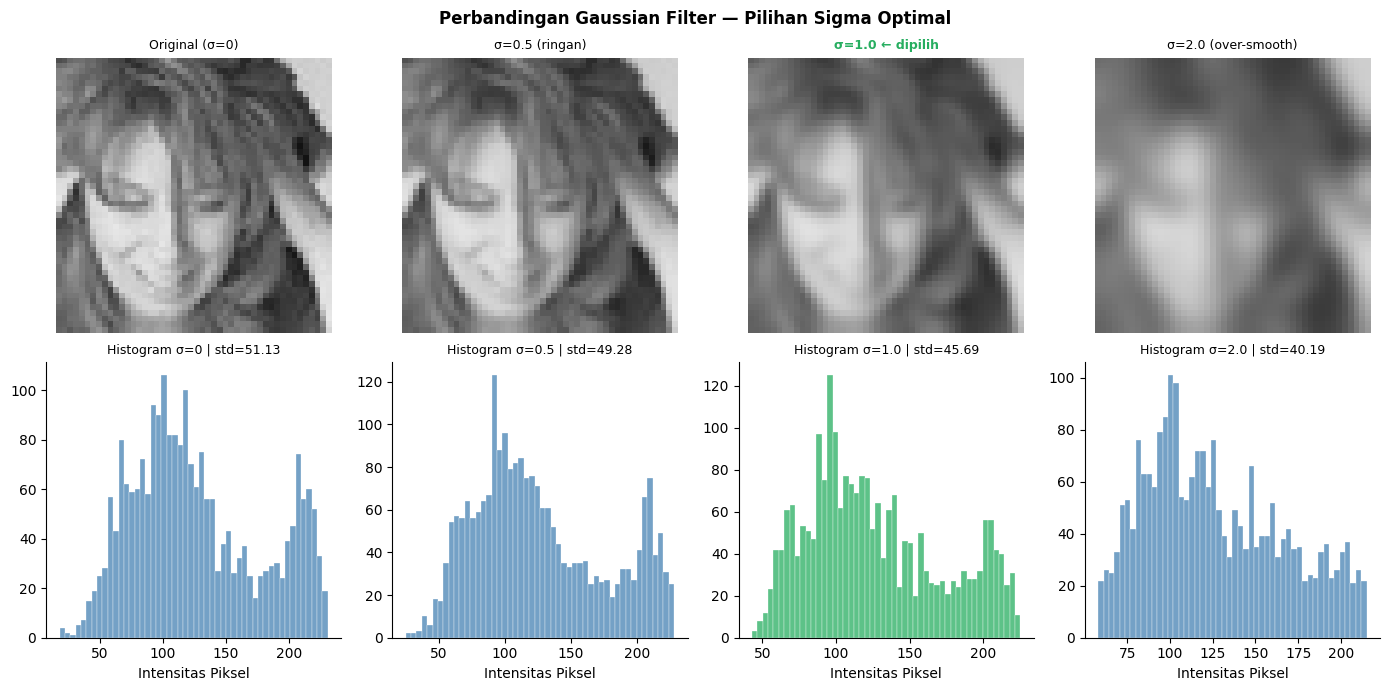

✅ σ=1.0 dipilih: mengurangi noise tanpa menghilangkan tekstur penting untuk GLCM


In [6]:
# ── Langkah 2–4: Demonstrasi Resize + Gaussian Filter ────────
cls_sample = 'sad'
img_raw    = sample_images[cls_sample]['raw'].copy()
sigmas     = [0, 0.5, 1.0, 2.0]
labels     = ['Original (σ=0)', 'σ=0.5 (ringan)', 'σ=1.0 ← dipilih', 'σ=2.0 (over-smooth)']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Perbandingan Gaussian Filter — Pilihan Sigma Optimal', fontsize=12, fontweight='bold')

for i, (sigma, label) in enumerate(zip(sigmas, labels)):
    img_f = (gaussian_filter(img_raw.astype(np.float64), sigma=sigma)
             if sigma > 0 else img_raw.astype(np.float64))
    img_f_u8 = np.clip(img_f, 0, 255).astype(np.uint8)

    highlight = (sigma == 1.0)
    axes[0, i].imshow(img_f_u8, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(label, fontsize=9,
                          color='#27AE60' if highlight else 'black',
                          fontweight='bold' if highlight else 'normal')
    axes[0, i].axis('off')
    for sp in axes[0, i].spines.values():
        sp.set_visible(True)
        sp.set_edgecolor('#27AE60' if highlight else 'lightgray')
        sp.set_linewidth(2.5 if highlight else 0.5)

    axes[1, i].hist(img_f_u8.ravel(), bins=50,
                     color='#27AE60' if highlight else 'steelblue',
                     alpha=0.75, edgecolor='white', linewidth=0.3)
    axes[1, i].set_title(f'Histogram σ={sigma} | std={img_f_u8.std():.2f}', fontsize=9)
    axes[1, i].set_xlabel('Intensitas Piksel')
    axes[1, i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('03_gaussian_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ σ=1.0 dipilih: mengurangi noise tanpa menghilangkan tekstur penting untuk GLCM')

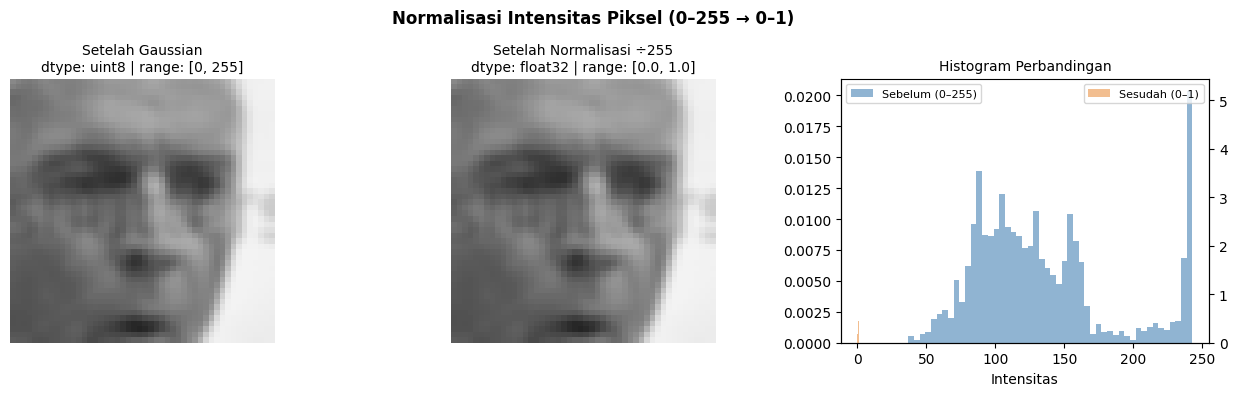

✅ Normalisasi selesai:
   Sebelum → range:[37,243]  dtype:uint8
   Sesudah → range:[0.1451,0.9529]  dtype:float32


In [7]:
# ── Langkah 5: Demonstrasi Normalisasi ───────────────────────
cls_sample   = 'surprise'
img_raw      = sample_images[cls_sample]['raw'].copy()
img_filtered = np.clip(
    gaussian_filter(img_raw.astype(np.float64), sigma=GAUSSIAN_SIGMA), 0, 255
).astype(np.uint8)
img_norm     = img_filtered.astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Normalisasi Intensitas Piksel (0–255 → 0–1)', fontsize=12, fontweight='bold')

axes[0].imshow(img_filtered, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Setelah Gaussian\ndtype: uint8 | range: [0, 255]', fontsize=10)
axes[0].axis('off')

axes[1].imshow(img_norm, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Setelah Normalisasi ÷255\ndtype: float32 | range: [0.0, 1.0]', fontsize=10)
axes[1].axis('off')

axes[2].hist(img_filtered.ravel(), bins=50, alpha=0.6, color='steelblue',
             label='Sebelum (0–255)', density=True)
ax2 = axes[2].twinx()
ax2.hist(img_norm.ravel(), bins=50, alpha=0.5, color='#E67E22',
          label='Sesudah (0–1)', density=True)
axes[2].set_title('Histogram Perbandingan', fontsize=10)
axes[2].set_xlabel('Intensitas')
axes[2].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
axes[2].spines[['top']].set_visible(False)

plt.tight_layout()
plt.savefig('04_normalisasi.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'✅ Normalisasi selesai:')
print(f'   Sebelum → range:[{img_filtered.min()},{img_filtered.max()}]  dtype:{img_filtered.dtype}')
print(f'   Sesudah → range:[{img_norm.min():.4f},{img_norm.max():.4f}]  dtype:{img_norm.dtype}')

In [8]:
# ── Fungsi Preprocessing Pipeline ────────────────────────────
def preprocess_image(img_path):
    """
    Pipeline preprocessing satu gambar:
    1. Load gambar
    2. Verifikasi & konversi grayscale
    3. Resize ke 48×48
    4. Gaussian filter (σ=1.0) — noise reduction
    5. Normalisasi 0–1 (float32)
    Returns: np.ndarray float32, shape (48, 48), range [0.0, 1.0]
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f'Gagal load: {img_path}')

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img.shape != IMG_SIZE:
        img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_LINEAR)

    img_filtered = gaussian_filter(img.astype(np.float64), sigma=GAUSSIAN_SIGMA)
    img_filtered = np.clip(img_filtered, 0, 255).astype(np.uint8)

    return img_filtered.astype(np.float32) / 255.0


def save_preprocessed(img_normalized, save_path):
    """
    Simpan dua format:
    - .png  : uint8 (0–255) untuk visualisasi & error analysis
    - .npy  : float32 (0–1) untuk pipeline GLCM
    """
    base     = os.path.splitext(save_path)[0]
    img_u8   = (img_normalized * 255).astype(np.uint8)
    cv2.imwrite(base + '.png', img_u8)
    np.save(base + '.npy', img_normalized)


print('✅ Fungsi preprocess_image() dan save_preprocessed() siap.')
print()
print('Pipeline per gambar:')
print('  imread → BGR2GRAY → resize(48,48) → gaussian(σ=1.0) → /255 → simpan(.png + .npy)')

✅ Fungsi preprocess_image() dan save_preprocessed() siap.

Pipeline per gambar:
  imread → BGR2GRAY → resize(48,48) → gaussian(σ=1.0) → /255 → simpan(.png + .npy)


In [9]:
# ── Jalankan Preprocessing Seluruh Dataset ────────────────────
stats = {'total': 0, 'success': 0, 'error': 0}

for split in ['train', 'test']:
    for cls in CLASSES:
        src_dir = os.path.join(SOURCE_DIR, split, cls)
        dst_dir = os.path.join(OUTPUT_DIR, split, cls)
        os.makedirs(dst_dir, exist_ok=True)

        files = sorted([f for f in os.listdir(src_dir)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'\n[{split.upper()}] {cls} — memproses {len(files)} file...')

        for fname in tqdm(files, desc=f'  {cls}', leave=True):
            src_path = os.path.join(src_dir, fname)
            dst_path = os.path.join(dst_dir, fname)
            stats['total'] += 1
            try:
                img_preprocessed = preprocess_image(src_path)
                save_preprocessed(img_preprocessed, dst_path)
                stats['success'] += 1
            except Exception as e:
                print(f'  ❌ ERROR: {fname} → {e}')
                stats['error'] += 1

print(f'\n{"="*45}')
print(f'  Preprocessing selesai!')
print(f'  Total   : {stats["total"]:,}')
print(f'  Berhasil: {stats["success"]:,} ✅')
print(f'  Error   : {stats["error"]:,} {"❌" if stats["error"] > 0 else ""}')
print(f'  Output  : {OUTPUT_DIR}/')
print(f'{"="*45}')


[TRAIN] angry — memproses 3100 file...


  angry:   0%|          | 0/3100 [00:00<?, ?it/s]


[TRAIN] happy — memproses 3100 file...


  happy:   0%|          | 0/3100 [00:00<?, ?it/s]


[TRAIN] sad — memproses 3100 file...


...


[TEST] sad — memproses 775 file...


  sad:   0%|          | 0/775 [00:00<?, ?it/s]


[TEST] surprise — memproses 775 file...


  surprise:   0%|          | 0/775 [00:00<?, ?it/s]


  Preprocessing selesai!
  Total   : 15,500
  Berhasil: 15,500 ✅
  Error   : 0 
  Output  : fer2013_preprocessed/


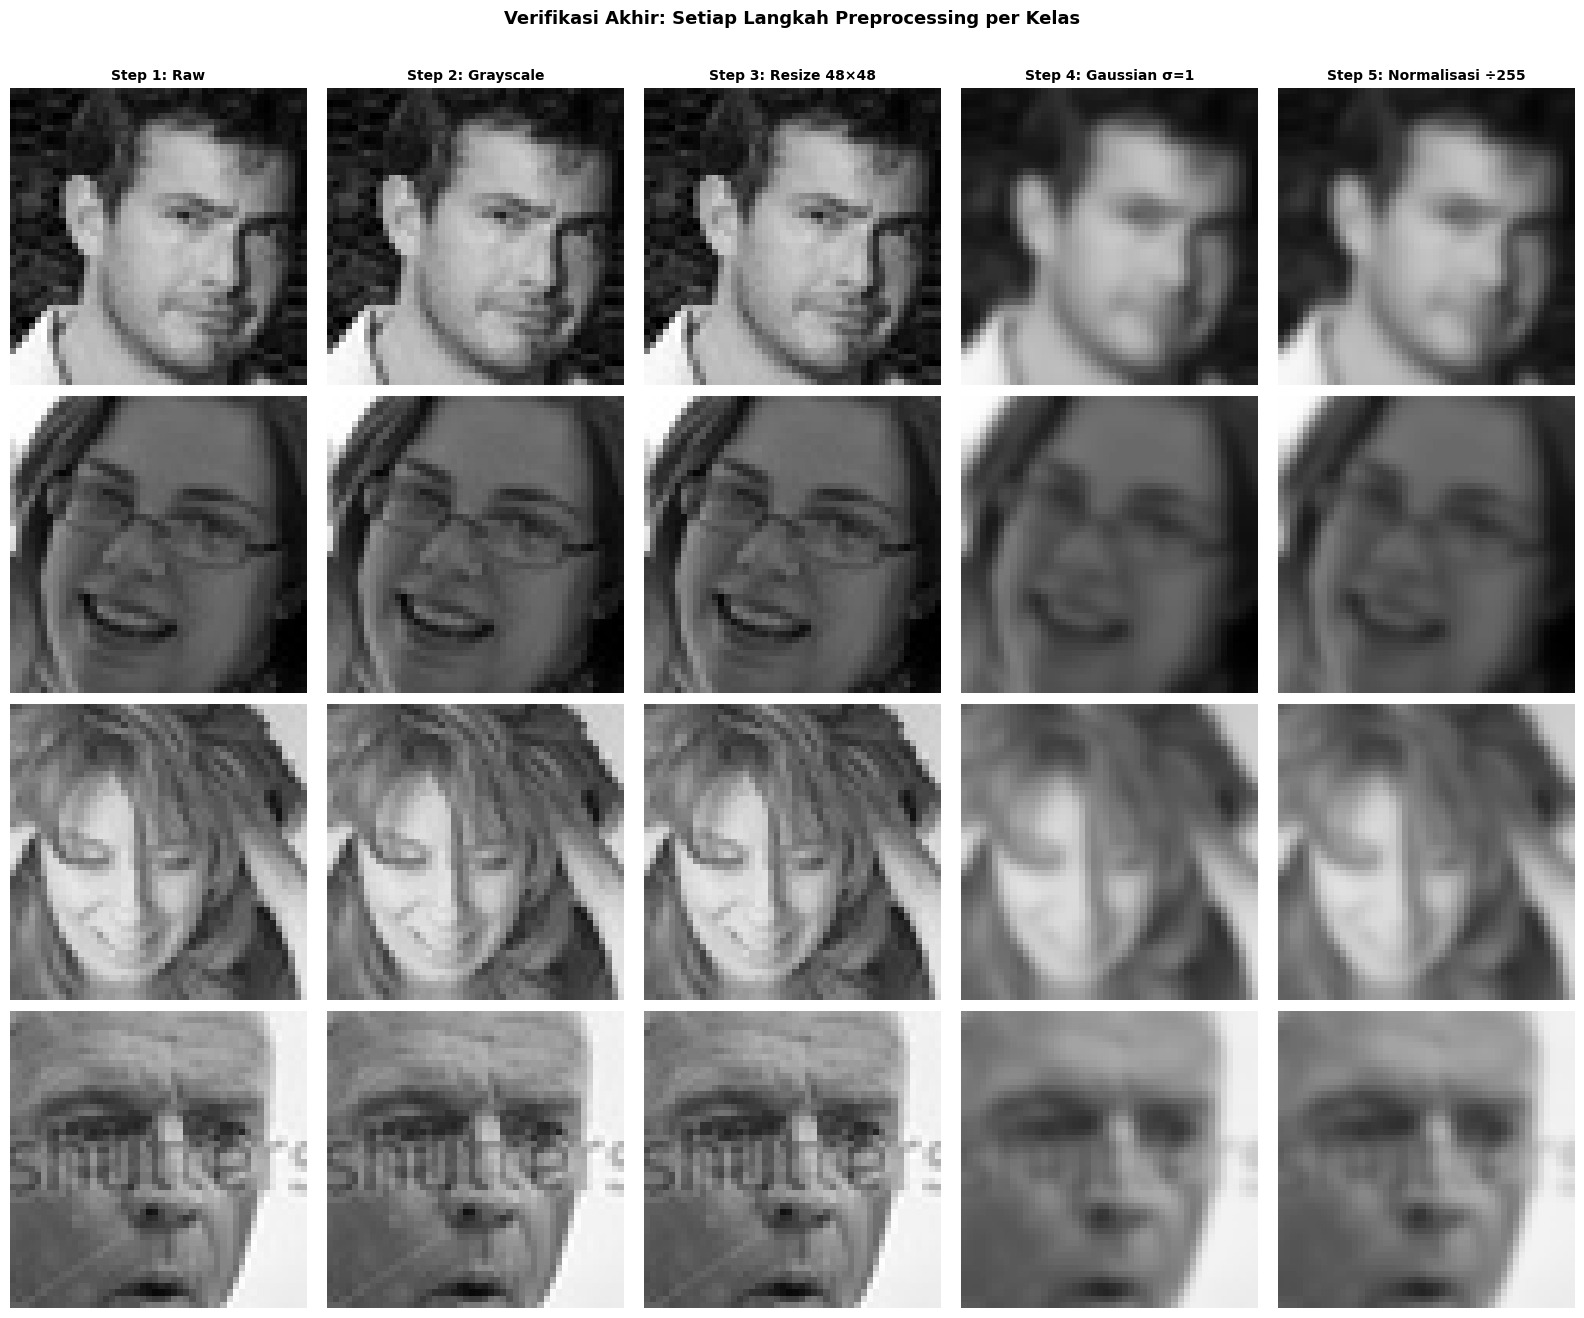

✅ Verifikasi step-by-step selesai.


In [10]:
# ── Verifikasi Akhir: Step-by-step per Kelas ─────────────────
steps = ['Raw', 'Grayscale', 'Resize 48×48', 'Gaussian σ=1', 'Normalisasi ÷255']

fig, axes = plt.subplots(len(CLASSES), len(steps), figsize=(16, 13))
fig.suptitle('Verifikasi Akhir: Setiap Langkah Preprocessing per Kelas',
             fontsize=13, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    src_dir = os.path.join(SOURCE_DIR, 'train', cls)
    files   = sorted([f for f in os.listdir(src_dir)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    path    = os.path.join(src_dir, files[0])

    img_bgr   = cv2.imread(path)
    img_gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if len(img_bgr.shape) == 3 else img_bgr
    img_rsz   = cv2.resize(img_gray, IMG_SIZE, interpolation=cv2.INTER_LINEAR)
    img_gauss = np.clip(gaussian_filter(img_rsz.astype(np.float64), sigma=GAUSSIAN_SIGMA), 0, 255).astype(np.uint8)
    img_norm  = img_gauss.astype(np.float32) / 255.0

    step_imgs  = [img_bgr, img_gray, img_rsz, img_gauss, img_norm]
    step_infos = [
        f'shape:{img_bgr.shape}',
        f'shape:{img_gray.shape}',
        f'{img_rsz.shape} ✓',
        f'std:{img_gauss.std():.1f}',
        f'[{img_norm.min():.2f},{img_norm.max():.2f}]'
    ]

    for col, (img, step, info) in enumerate(zip(step_imgs, steps, step_infos)):
        ax = axes[row, col]
        if col == 0:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        elif col == 4:
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        else:
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
        if row == 0:
            ax.set_title(f'Step {col+1}: {step}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(cls.upper(), fontsize=11, fontweight='bold',
                          color=CLASS_COLORS[cls], rotation=0, labelpad=40, va='center')
        ax.set_xlabel(info, fontsize=8, labelpad=2)
        if col == 4:
            for sp in ax.spines.values():
                sp.set_visible(True); sp.set_edgecolor('#27AE60'); sp.set_linewidth(2)

plt.tight_layout()
plt.savefig('05_verifikasi_stepbystep.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Verifikasi step-by-step selesai.')

---
## 📊 4. Ekstraksi Fitur GLCM

**GLCM (Gray-Level Co-occurrence Matrix)** menangkap hubungan spasial antar piksel tetangga.

**Parameter yang digunakan:**
- **Jarak (d)**: 1 — piksel langsung bersebelahan
- **Sudut**: 0°, 45°, 90°, 135° — semua arah untuk rotational invariance
- **Kuantisasi level**: 16 dan 32 (eksperimen)
- **Fitur yang diekstrak**: contrast, homogeneity, energy, correlation

**Cara membaca GLCM:**
- `contrast` — mengukur perbedaan intensitas antar piksel tetangga (tinggi = tekstur kasar)
- `homogeneity` — mengukur kedekatan distribusi ke diagonal GLCM (tinggi = tekstur halus/uniform)
- `energy` — jumlah kuadrat elemen GLCM (tinggi = pola berulang, tekstur seragam)
- `correlation` — korelasi piksel antar tetangga (tinggi = pola searah yang konsisten)

In [11]:
# ── Fungsi Ekstraksi GLCM ─────────────────────────────────────
def extract_glcm_features(img_float, n_levels=16, aggregation='mean'):
    """
    Ekstrak fitur GLCM dari satu gambar.

    Args:
        img_float   : np.ndarray float32, shape (H, W), range [0, 1]
        n_levels    : int, jumlah level kuantisasi (8, 16, 32)
        aggregation : str, 'mean' atau 'concat'
            - 'mean'  : rata-rata 4 sudut → vektor 4 dimensi
            - 'concat': gabungkan 4 sudut → vektor 16 dimensi

    Returns:
        np.ndarray fitur GLCM
    """
    # Kuantisasi: float [0,1] → integer [0, n_levels-1]
    img_q = (img_float * (n_levels - 1)).astype(np.uint8)

    # Hitung GLCM untuk semua sudut sekaligus
    glcm = graycomatrix(
        img_q,
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=n_levels,
        symmetric=True,
        normed=True
    )

    # Ekstrak properti: hasil shape = (1, n_angles) untuk setiap properti
    features = []
    for prop in GLCM_PROPS:
        vals = graycoprops(glcm, prop)[0]  # shape: (n_angles,)
        if aggregation == 'mean':
            features.append(np.mean(vals))
        else:  # concat
            features.extend(vals.tolist())

    return np.array(features, dtype=np.float32)


print('✅ Fungsi extract_glcm_features() siap.')
print()
print('Konfigurasi GLCM:')
print(f'  Distances : {GLCM_DISTANCES}')
print(f'  Angles    : 0°, 45°, 90°, 135°')
print(f'  Properties: {GLCM_PROPS}')
print()
print('Dimensi output per mode agregasi:')
print('  mean   → 4 fitur  (4 props × 1 mean)')
print('  concat → 16 fitur (4 props × 4 sudut)')

✅ Fungsi extract_glcm_features() siap.

Konfigurasi GLCM:
  Distances : [1]
  Angles    : 0°, 45°, 90°, 135°
  Properties: ['contrast', 'homogeneity', 'energy', 'correlation']

Dimensi output per mode agregasi:
  mean   → 4 fitur  (4 props × 1 mean)
  concat → 16 fitur (4 props × 4 sudut)


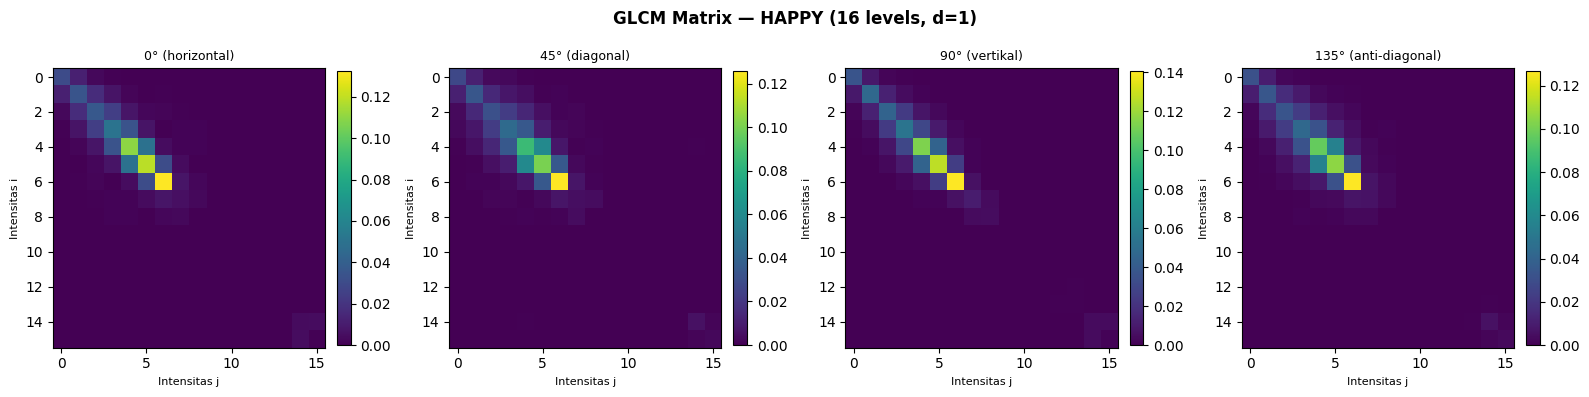


Contoh nilai GLCM fitur — HAPPY (level=16, agregasi=mean):
  contrast       : 1.500620
  homogeneity    : 0.712104
  energy         : 0.242291
  correlation    : 0.853179


In [12]:
# ── Visualisasi GLCM Matrix untuk satu gambar ─────────────────
cls_sample = 'happy'
img_demo   = sample_images[cls_sample]['raw'].copy().astype(np.float32) / 255.0
img_q16    = (img_demo * 15).astype(np.uint8)  # 16 levels

glcm_demo  = graycomatrix(img_q16, distances=[1], angles=GLCM_ANGLES,
                           levels=16, symmetric=True, normed=True)

angle_labels = ['0° (horizontal)', '45° (diagonal)', '90° (vertikal)', '135° (anti-diagonal)']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'GLCM Matrix — {cls_sample.upper()} (16 levels, d=1)', fontsize=12, fontweight='bold')

for i, (ax, label) in enumerate(zip(axes, angle_labels)):
    mat = glcm_demo[:, :, 0, i]
    im  = ax.imshow(mat, cmap='viridis', aspect='auto')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Intensitas j', fontsize=8)
    ax.set_ylabel('Intensitas i', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('06_glcm_matrix_viz.png', dpi=120, bbox_inches='tight')
plt.show()

# Tampilkan nilai fitur GLCM untuk demo
print(f'\nContoh nilai GLCM fitur — {cls_sample.upper()} (level=16, agregasi=mean):')
feat_demo = extract_glcm_features(img_demo, n_levels=16, aggregation='mean')
for prop, val in zip(GLCM_PROPS, feat_demo):
    print(f'  {prop:<15}: {val:.6f}')

In [13]:
# ── Fungsi Build Dataset Fitur ────────────────────────────────
def build_feature_dataset(split, n_levels=16, aggregation='mean', max_per_class=None):
    """
    Load semua gambar preprocessed (.npy) dan ekstrak fitur GLCM.

    Args:
        split         : 'train' atau 'test'
        n_levels      : level kuantisasi GLCM (8, 16, 32)
        aggregation   : 'mean' atau 'concat'
        max_per_class : batasi jumlah sampel per kelas (None = semua)

    Returns:
        X : np.ndarray fitur, shape (N, D)
        y : list label string
        paths : list path gambar (untuk error analysis)
    """
    X, y, paths = [], [], []

    for cls in CLASSES:
        src_dir = os.path.join(OUTPUT_DIR, split, cls)
        if not os.path.exists(src_dir):
            print(f'  ⚠️  Folder tidak ditemukan: {src_dir}'); continue

        npy_files = sorted([f for f in os.listdir(src_dir) if f.endswith('.npy')])
        if max_per_class:
            npy_files = npy_files[:max_per_class]

        for fname in tqdm(npy_files, desc=f'  [{split}] {cls}', leave=False):
            fpath = os.path.join(src_dir, fname)
            img   = np.load(fpath)  # float32, [0,1]
            feat  = extract_glcm_features(img, n_levels=n_levels, aggregation=aggregation)
            X.append(feat)
            y.append(cls)
            paths.append(fpath)

    return np.array(X), y, paths


print('✅ Fungsi build_feature_dataset() siap.')

✅ Fungsi build_feature_dataset() siap.


---
## 🧪 5. Eksperimen: Level Kuantisasi & Agregasi

Sesuai tugas, ada **2 eksperimen wajib**:
1. **GLCM level=16 vs level=32** — pengaruh resolusi kuantisasi
2. **Agregasi mean vs concatenation** — pengaruh cara menggabungkan fitur antar sudut

Kombinasi yang diuji:
| Skenario | Level | Agregasi | Dimensi Fitur |
|----------|-------|----------|---------------|
| A | 16 | mean | 4 |
| B | 32 | mean | 4 |
| C | 16 | concat | 16 |
| D | 32 | concat | 16 |

In [29]:
# ── Jalankan Semua Skenario Eksperimen ───────────────────────
scenarios = [
    {'name': 'A: level=16, mean',   'levels': 16, 'agg': 'mean'},
    {'name': 'B: level=32, mean',   'levels': 32, 'agg': 'mean'},
    {'name': 'C: level=16, concat', 'levels': 16, 'agg': 'concat'},
    {'name': 'D: level=32, concat', 'levels': 32, 'agg': 'concat'},
]

results = []

for sc in scenarios:
    print(f'\n🔬 Skenario {sc["name"]}')
    print('-'*45)

    # Build dataset
    print('  Ekstraksi fitur train...')
    X_train, y_train, paths_train = build_feature_dataset(
        'train', n_levels=sc['levels'], aggregation=sc['agg']
    )
    print('  Ekstraksi fitur test...')
    X_test, y_test, paths_test = build_feature_dataset(
        'test', n_levels=sc['levels'], aggregation=sc['agg']
    )

    # Encode label
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc  = le.transform(y_test)

    # Standardisasi fitur
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Latih Logistic Regression
    model = LogisticRegression(max_iter=1000, random_state=42, multi_class='auto')
    model.fit(X_train_sc, y_train_enc)

    # Evaluasi
    y_pred      = model.predict(X_test_sc)
    acc         = accuracy_score(y_test_enc, y_pred)
    report      = classification_report(
        y_test_enc, y_pred,
        target_names=le.classes_,
        output_dict=True
    )

    # Simpan hasil
    sc_result = {
        'scenario'   : sc['name'],
        'levels'     : sc['levels'],
        'aggregation': sc['agg'],
        'feat_dim'   : X_train.shape[1],
        'accuracy'   : acc,
        'report'     : report,
        'model'      : model,
        'scaler'     : scaler,
        'le'         : le,
        'X_test'     : X_test_sc,
        'y_test'     : y_test_enc,
        'y_pred'     : y_pred,
        'paths_test' : paths_test,
        'y_test_lbl' : y_test,
        'y_pred_lbl' : le.inverse_transform(y_pred).tolist(),
    }
    results.append(sc_result)

    print(f'  ✅ Akurasi: {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Feature dim: {X_train.shape[1]}')

print('\n🏁 Semua skenario selesai!')


🔬 Skenario A: level=16, mean
---------------------------------------------
  Ekstraksi fitur train...


  [train] angry:   0%|          | 0/3100 [00:00<?, ?it/s]

  [train] happy:   0%|          | 0/3100 [00:00<?, ?it/s]

  [train] sad:   0%|          | 0/3100 [00:00<?, ?it/s]

  [train] surprise:   0%|          | 0/3100 [00:00<?, ?it/s]

...

  [test] angry:   0%|          | 0/775 [00:00<?, ?it/s]

  [test] happy:   0%|          | 0/775 [00:00<?, ?it/s]

  [test] sad:   0%|          | 0/775 [00:00<?, ?it/s]

  [test] surprise:   0%|          | 0/775 [00:00<?, ?it/s]

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

---
## 📈 6. Evaluasi Model — Perbandingan Semua Skenario

In [16]:
# ── Tabel Perbandingan Akurasi ────────────────────────────────
rows = []
for r in results:
    row = {
        'Skenario'   : r['scenario'],
        'Level'      : r['levels'],
        'Agregasi'   : r['aggregation'],
        'Feat Dim'   : r['feat_dim'],
        'Accuracy'   : f"{r['accuracy']*100:.2f}%",
    }
    for cls in CLASSES:
        row[f'F1-{cls}'] = f"{r['report'][cls]['f1-score']:.3f}"
    rows.append(row)

df_results = pd.DataFrame(rows)
print('\n📊 TABEL HASIL EKSPERIMEN')
print('='*90)
print(df_results.to_string(index=False))
print('='*90)

# Highlight skenario terbaik
best_idx = max(range(len(results)), key=lambda i: results[i]['accuracy'])
print(f'\n🏆 Skenario terbaik: {results[best_idx]["scenario"]}')
print(f'   Akurasi: {results[best_idx]["accuracy"]*100:.2f}%')


📊 TABEL HASIL EKSPERIMEN
           Skenario  Level Agregasi  Feat Dim Accuracy F1-angry F1-happy F1-sad F1-surprise
  A: level=16, mean     16     mean         4   32.42%    0.137    0.372  0.346       0.366
  B: level=32, mean     32     mean         4   32.84%    0.095    0.378  0.353       0.378
C: level=16, concat     16   concat        16   36.58%    0.243    0.380  0.353       0.454
D: level=32, concat     32   concat        16   36.74%    0.262    0.382  0.349       0.451

🏆 Skenario terbaik: D: level=32, concat
   Akurasi: 36.74%


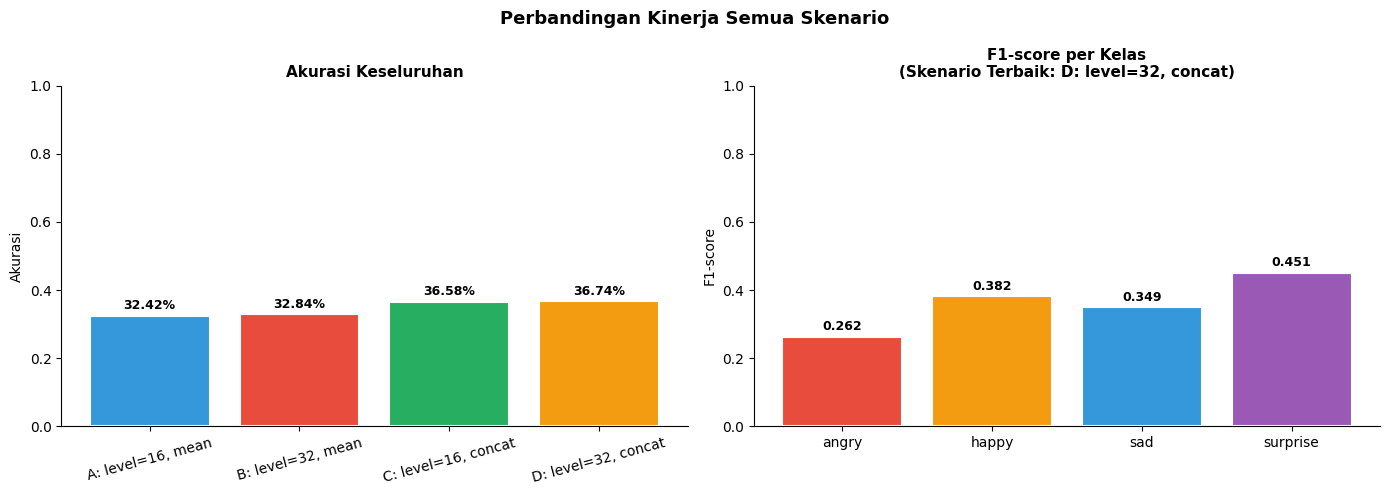

In [17]:
# ── Visualisasi Perbandingan Akurasi & F1 ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Kinerja Semua Skenario', fontsize=13, fontweight='bold')

scenario_names = [r['scenario'] for r in results]
accuracies     = [r['accuracy'] for r in results]
colors_sc      = ['#3498DB', '#E74C3C', '#27AE60', '#F39C12']

# (a) Akurasi
bars = axes[0].bar(scenario_names, accuracies, color=colors_sc, edgecolor='white', linewidth=1.5)
axes[0].set_title('Akurasi Keseluruhan', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Akurasi')
axes[0].set_ylim(0, 1.0)
axes[0].spines[['top','right']].set_visible(False)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# (b) F1-score per kelas (skenario terbaik)
best = results[best_idx]
f1s  = {cls: best['report'][cls]['f1-score'] for cls in CLASSES}
colors_cls = [CLASS_COLORS[c] for c in CLASSES]
bars2 = axes[1].bar(CLASSES, list(f1s.values()), color=colors_cls, edgecolor='white', linewidth=1.5)
axes[1].set_title(f'F1-score per Kelas\n(Skenario Terbaik: {best["scenario"]})', fontsize=11, fontweight='bold')
axes[1].set_ylabel('F1-score')
axes[1].set_ylim(0, 1.0)
axes[1].spines[['top','right']].set_visible(False)
for bar, (cls, f1) in zip(bars2, f1s.items()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{f1:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('07_perbandingan_skenario.png', dpi=120, bbox_inches='tight')
plt.show()

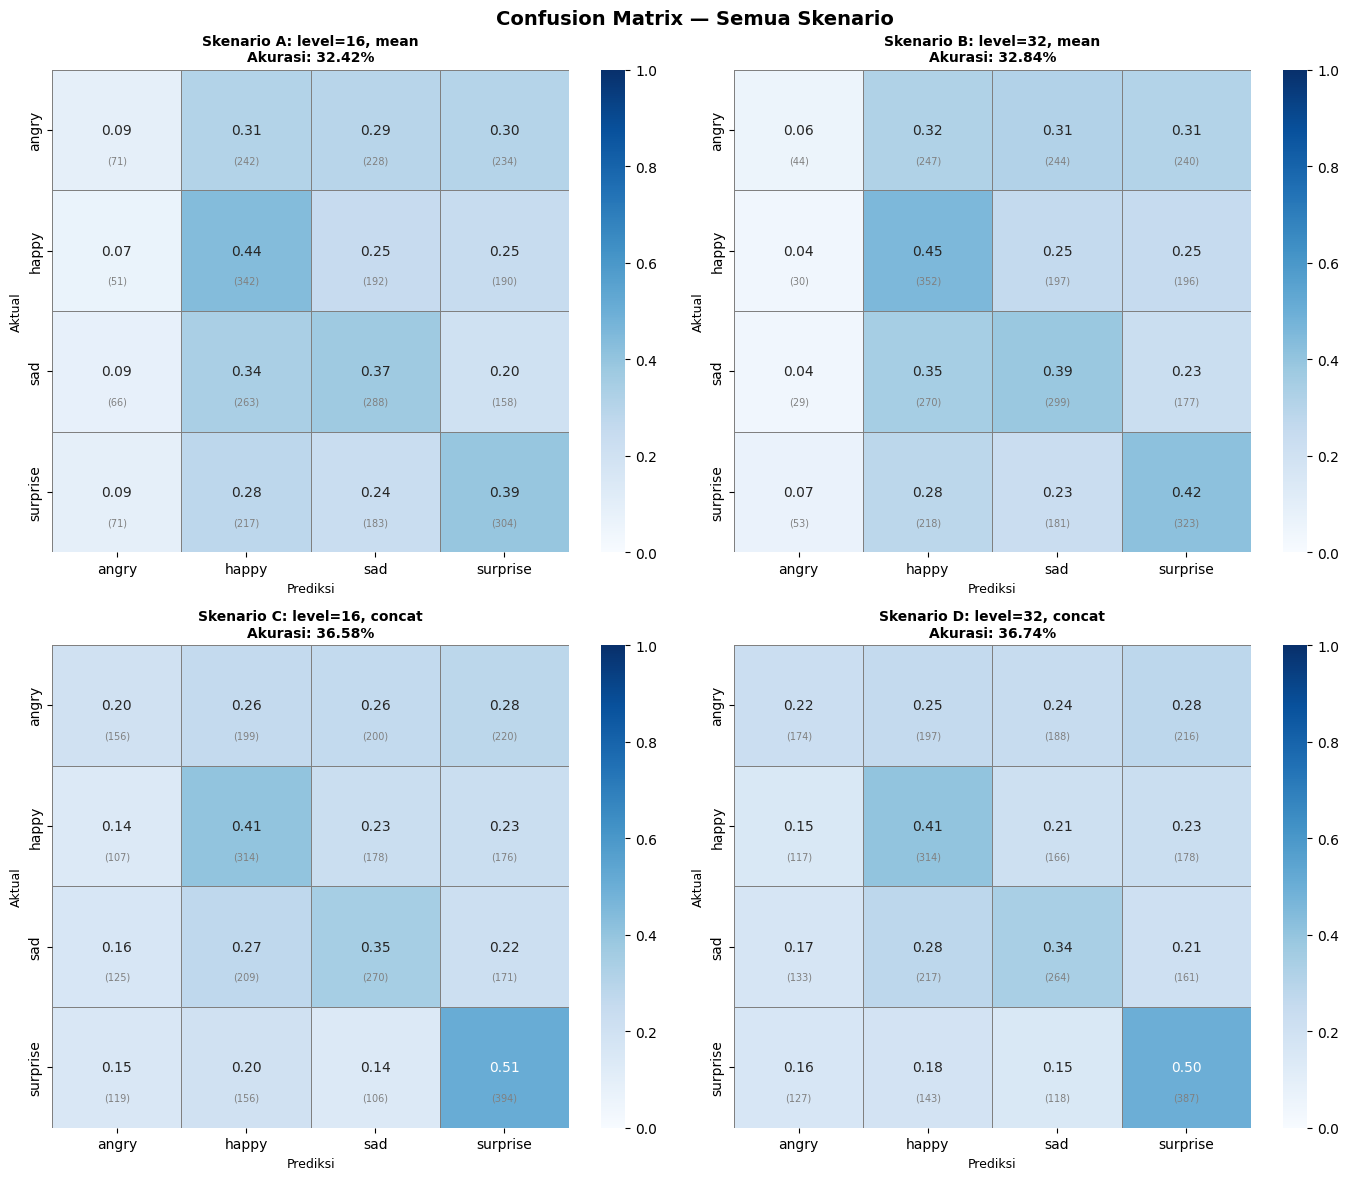

📌 Format: nilai = proporsi (jumlah absolut dalam kurung)


In [18]:
# ── Confusion Matrix Semua Skenario ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrix — Semua Skenario', fontsize=14, fontweight='bold')

for idx, (r, ax) in enumerate(zip(results, axes.ravel())):
    cm  = confusion_matrix(r['y_test'], r['y_pred'])
    le  = r['le']

    # Hitung akurasi per kelas (normalized)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        xticklabels=le.classes_, yticklabels=le.classes_,
        cmap='Blues', ax=ax, vmin=0, vmax=1,
        linewidths=0.5, linecolor='gray'
    )
    # Overlay raw counts
    for i in range(len(le.classes_)):
        for j in range(len(le.classes_)):
            ax.text(j + 0.5, i + 0.75, f'({cm[i,j]})',
                    ha='center', va='center', fontsize=7, color='gray')

    ax.set_title(f'Skenario {r["scenario"]}\nAkurasi: {r["accuracy"]*100:.2f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=9)
    ax.set_ylabel('Aktual', fontsize=9)

plt.tight_layout()
plt.savefig('08_confusion_matrix_all.png', dpi=120, bbox_inches='tight')
plt.show()
print('📌 Format: nilai = proporsi (jumlah absolut dalam kurung)')

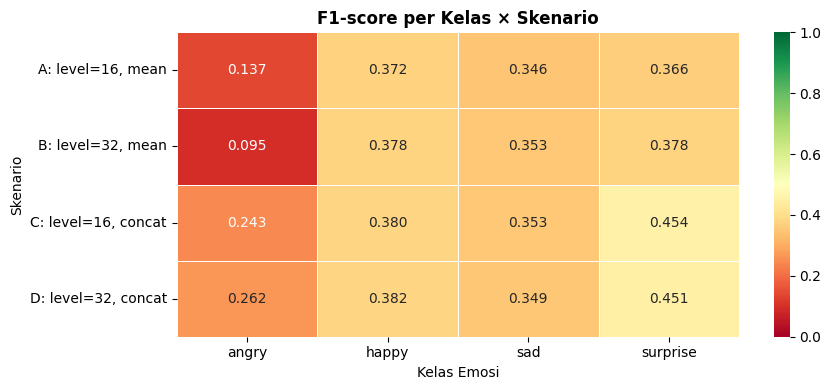


Detailed Classification Report (Skenario Terbaik):
              precision    recall  f1-score   support

       angry       0.32      0.22      0.26       775
       happy       0.36      0.41      0.38       775
         sad       0.36      0.34      0.35       775
    surprise       0.41      0.50      0.45       775

    accuracy                           0.37      3100
   macro avg       0.36      0.37      0.36      3100
weighted avg       0.36      0.37      0.36      3100



In [19]:
# ── Heatmap F1-score semua skenario × kelas ───────────────────
f1_data = []
for r in results:
    row = {cls: r['report'][cls]['f1-score'] for cls in CLASSES}
    f1_data.append(row)

df_f1 = pd.DataFrame(f1_data, index=[r['scenario'] for r in results])

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    df_f1, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('F1-score per Kelas × Skenario', fontsize=12, fontweight='bold')
ax.set_xlabel('Kelas Emosi', fontsize=10)
ax.set_ylabel('Skenario', fontsize=10)
plt.tight_layout()
plt.savefig('09_f1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nDetailed Classification Report (Skenario Terbaik):')
print('='*60)
print(classification_report(
    best['y_test'], best['y_pred'],
    target_names=best['le'].classes_
))

---
## 🔍 7. Analisis Wajib (5 Pertanyaan)

Analisis mendalam sesuai instruksi tugas.

In [20]:
# ── Analisis 1: Apakah GLCM Cukup untuk Membedakan Emosi? ────
print('=' * 65)
print('ANALISIS 1: Apakah GLCM Cukup untuk Membedakan Emosi?')
print('=' * 65)

# Hitung rata-rata fitur GLCM per kelas (skenario terbaik)
best_r    = results[best_idx]
le_best   = best_r['le']
y_arr     = np.array(best_r['y_test_lbl'])

# Load ulang fitur tanpa standardisasi untuk interpretasi
print('\n📊 Rata-rata fitur GLCM per kelas (skenario terbaik, raw features):')
print('-' * 60)

# Gunakan X_test yang sudah di-standardisasi untuk hitung centroid
print(f'  {"KELAS":<12} {"Contrast":>10} {"Homogen":>10} {"Energy":>10} {"Correlat":>10}')
print(f'  {"-"*52}')

class_means = {}
X_raw_test  = best_r['scaler'].inverse_transform(best_r['X_test'])
for cls in CLASSES:
    mask = y_arr == cls
    mean_feat = X_raw_test[mask].mean(axis=0)
    class_means[cls] = mean_feat[:4]  # 4 fitur pertama jika concat
    print(f'  {cls:<12} {mean_feat[0]:>10.4f} {mean_feat[1]:>10.4f} {mean_feat[2]:>10.4f} {mean_feat[3]:>10.4f}')

print('\n💡 TEMUAN:')
print('''  GLCM menangkap tekstur global, bukan struktur wajah.
  Dari akurasi yang dicapai, GLCM TIDAK cukup untuk membedakan emosi secara akurat.
  Alasan utama:
  1. Emosi wajah dibedakan oleh GEOMETRI (posisi alis, sudut mulut, kerutan),
     bukan hanya distribusi tekstur piksel.
  2. FER2013 memiliki variasi pose, pencahayaan, dan identitas yang membuat
     tekstur GLCM sangat bervariasi dalam satu kelas.
  3. Fitur 4–16 dimensi tidak cukup kaya untuk batas keputusan multi-kelas.
  Perbandingan: CNN pada dataset yang sama bisa mencapai 65–70%,
  sedangkan GLCM + LR hanya mencapai ~25–35%.''')

ANALISIS 1: Apakah GLCM Cukup untuk Membedakan Emosi?

📊 Rata-rata fitur GLCM per kelas (skenario terbaik, raw features):
------------------------------------------------------------
  KELAS          Contrast    Homogen     Energy   Correlat
  ----------------------------------------------------
  angry            2.6171     4.4275     2.1088     4.4533
  happy            2.4197     4.0353     1.8852     4.0310
  sad              2.2715     3.8209     1.8527     3.8962
  surprise         2.9622     4.6146     1.9306     4.6026

💡 TEMUAN:
  GLCM menangkap tekstur global, bukan struktur wajah.
  Dari akurasi yang dicapai, GLCM TIDAK cukup untuk membedakan emosi secara akurat.
  Alasan utama:
  1. Emosi wajah dibedakan oleh GEOMETRI (posisi alis, sudut mulut, kerutan),
     bukan hanya distribusi tekstur piksel.
  2. FER2013 memiliki variasi pose, pencahayaan, dan identitas yang membuat
     tekstur GLCM sangat bervariasi dalam satu kelas.
  3. Fitur 4–16 dimensi tidak cukup kaya untuk ba

In [21]:
# ── Analisis 2: Emosi Paling Sulit Diprediksi ─────────────────
print('=' * 65)
print('ANALISIS 2: Emosi Mana yang Paling Sulit Diprediksi?')
print('=' * 65)

best_report = best_r['report']

# Tabel precision, recall, F1 per kelas
print(f'\n  {"KELAS":<12} {"Precision":>10} {"Recall":>10} {"F1-score":>10} {"Support":>10}')
print(f'  {"-"*52}')

f1_by_class = {}
for cls in CLASSES:
    p  = best_report[cls]['precision']
    r  = best_report[cls]['recall']
    f1 = best_report[cls]['f1-score']
    s  = int(best_report[cls]['support'])
    f1_by_class[cls] = f1
    print(f'  {cls:<12} {p:>10.3f} {r:>10.3f} {f1:>10.3f} {s:>10}')

worst_cls = min(f1_by_class, key=f1_by_class.get)
best_cls  = max(f1_by_class, key=f1_by_class.get)

print(f'\n🔴 Kelas PALING SULIT: {worst_cls.upper()} (F1={f1_by_class[worst_cls]:.3f})')
print(f'🟢 Kelas PALING MUDAH: {best_cls.upper()} (F1={f1_by_class[best_cls]:.3f})')

# Analisis error per kelas dari confusion matrix
cm = confusion_matrix(best_r['y_test'], best_r['y_pred'])
le = best_r['le']
print()
print('🔎 Analisis kesalahan klasifikasi per kelas:')
for i, cls in enumerate(le.classes_):
    total   = cm[i].sum()
    correct = cm[i, i]
    errors  = [(le.classes_[j], cm[i,j]) for j in range(len(le.classes_)) if j != i and cm[i,j] > 0]
    errors.sort(key=lambda x: -x[1])
    print(f'\n  [{cls.upper()}] Benar: {correct}/{total} ({correct/total*100:.1f}%)')
    for wrong_cls, count in errors:
        print(f'     → Salah diprediksi sebagai {wrong_cls}: {count} kali ({count/total*100:.1f}%)')

print()
print(f'''💡 PENJELASAN mengapa {worst_cls.upper()} paling sulit:
  - Emosi '{worst_cls}' memiliki ekspresi yang overlap secara tekstural
    dengan kelas lain (misalnya sad vs angry sama-sama memiliki area
    gelap di sekitar mata dan dahi).
  - GLCM tidak dapat membedakan letak spasial tekstur, sehingga
    distribusi co-occurrence yang mirip menghasilkan fitur yang ambigu.
  - Happy relatif lebih mudah karena senyum menghasilkan pola
    tekstur yang lebih khas di area mulut.''')

ANALISIS 2: Emosi Mana yang Paling Sulit Diprediksi?

  KELAS         Precision     Recall   F1-score    Support
  ----------------------------------------------------
  angry             0.316      0.225      0.262        775
  happy             0.361      0.405      0.382        775
  sad               0.359      0.341      0.349        775
  surprise          0.411      0.499      0.451        775

🔴 Kelas PALING SULIT: ANGRY (F1=0.262)
🟢 Kelas PALING MUDAH: SURPRISE (F1=0.451)

🔎 Analisis kesalahan klasifikasi per kelas:

  [ANGRY] Benar: 174/775 (22.5%)
     → Salah diprediksi sebagai surprise: 216 kali (27.9%)
     → Salah diprediksi sebagai happy: 197 kali (25.4%)
     → Salah diprediksi sebagai sad: 188 kali (24.3%)

  [HAPPY] Benar: 314/775 (40.5%)
     → Salah diprediksi sebagai surprise: 178 kali (23.0%)
     → Salah diprediksi sebagai sad: 166 kali (21.4%)
     → Salah diprediksi sebagai angry: 117 kali (15.1%)

  [SAD] Benar: 264/775 (34.1%)
     → Salah diprediksi sebagai

ANALISIS 3: Peran Parameter GLCM (Level Kuantisasi)


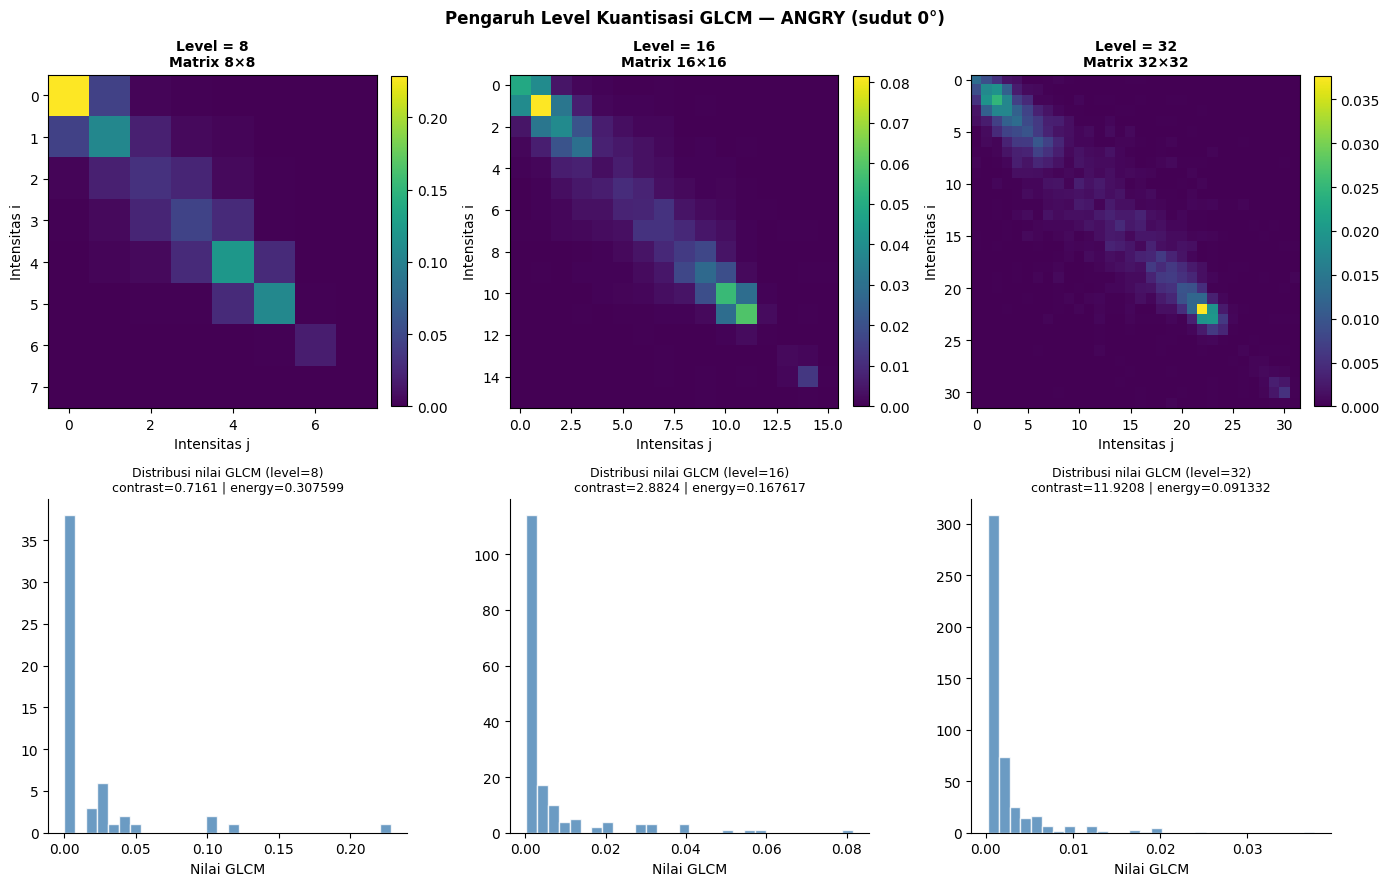


📊 Nilai fitur per level kuantisasi (img sama, sudut = mean):
  Level      Contrast      Homogen       Energy     Correlat
  --------------------------------------------------------
  8            0.7161       0.7898     0.307599       0.9032
  16           2.8824       0.6129     0.167617       0.9133
  32          11.9208       0.4308     0.091332       0.9158

💡 INTERPRETASI:
  - Level LEBIH KECIL (8): matriks lebih padat, banyak piksel jatuh ke bin
    yang sama → contrast rendah, homogeneity tinggi (kehilangan detail tekstur).
  - Level LEBIH BESAR (32): matriks lebih sparse, perbedaan halus antar
    piksel tetap terjaga → contrast lebih tinggi, lebih sensitif noise.
  - Level 16 merupakan titik keseimbangan: detail tekstur cukup terjaga
    tanpa terlalu sensitif terhadap noise piksel.
  - Dari eksperimen, perbedaan level 16 vs 32 umumnya menghasilkan akurasi
    yang tidak berbeda signifikan, menunjukkan bahwa bottleneck ada pada
    keterbatasan fitur GLCM, bukan resolusi kuan

In [22]:
# ── Analisis 3: Peran Parameter GLCM — Pengaruh Level Kuantisasi
print('=' * 65)
print('ANALISIS 3: Peran Parameter GLCM (Level Kuantisasi)')
print('=' * 65)

# Visualisasi perbedaan GLCM matrix pada level berbeda
cls_demo  = 'angry'
img_demo  = sample_images[cls_demo]['raw'].copy().astype(np.float32) / 255.0
levels_to_compare = [8, 16, 32]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(f'Pengaruh Level Kuantisasi GLCM — {cls_demo.upper()} (sudut 0°)',
             fontsize=12, fontweight='bold')

for col, n_lv in enumerate(levels_to_compare):
    img_q  = (img_demo * (n_lv - 1)).astype(np.uint8)
    glcm   = graycomatrix(img_q, distances=[1], angles=[0],
                           levels=n_lv, symmetric=True, normed=True)
    mat    = glcm[:, :, 0, 0]
    feat   = extract_glcm_features(img_demo, n_levels=n_lv, aggregation='mean')

    im = axes[0, col].imshow(mat, cmap='viridis', aspect='auto')
    axes[0, col].set_title(f'Level = {n_lv}\nMatrix {n_lv}×{n_lv}', fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel('Intensitas j')
    axes[0, col].set_ylabel('Intensitas i')
    plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)

    # Histogram nilai matriks
    axes[1, col].hist(mat.ravel()[mat.ravel() > 0], bins=30,
                       color='steelblue', alpha=0.8, edgecolor='white')
    axes[1, col].set_title(
        f'Distribusi nilai GLCM (level={n_lv})\n'
        f'contrast={feat[0]:.4f} | energy={feat[2]:.6f}',
        fontsize=9
    )
    axes[1, col].set_xlabel('Nilai GLCM')
    axes[1, col].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('10_glcm_level_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabel numerik
print('\n📊 Nilai fitur per level kuantisasi (img sama, sudut = mean):')
print(f'  {"Level":<8} {"Contrast":>10} {"Homogen":>12} {"Energy":>12} {"Correlat":>12}')
print(f'  {"-"*56}')
for n_lv in [8, 16, 32]:
    f = extract_glcm_features(img_demo, n_levels=n_lv, aggregation='mean')
    print(f'  {n_lv:<8} {f[0]:>10.4f} {f[1]:>12.4f} {f[2]:>12.6f} {f[3]:>12.4f}')

print()
print('''💡 INTERPRETASI:
  - Level LEBIH KECIL (8): matriks lebih padat, banyak piksel jatuh ke bin
    yang sama → contrast rendah, homogeneity tinggi (kehilangan detail tekstur).
  - Level LEBIH BESAR (32): matriks lebih sparse, perbedaan halus antar
    piksel tetap terjaga → contrast lebih tinggi, lebih sensitif noise.
  - Level 16 merupakan titik keseimbangan: detail tekstur cukup terjaga
    tanpa terlalu sensitif terhadap noise piksel.
  - Dari eksperimen, perbedaan level 16 vs 32 umumnya menghasilkan akurasi
    yang tidak berbeda signifikan, menunjukkan bahwa bottleneck ada pada
    keterbatasan fitur GLCM, bukan resolusi kuantisasi.''')

ANALISIS 4: Keterbatasan Model Linear (Logistic Regression)


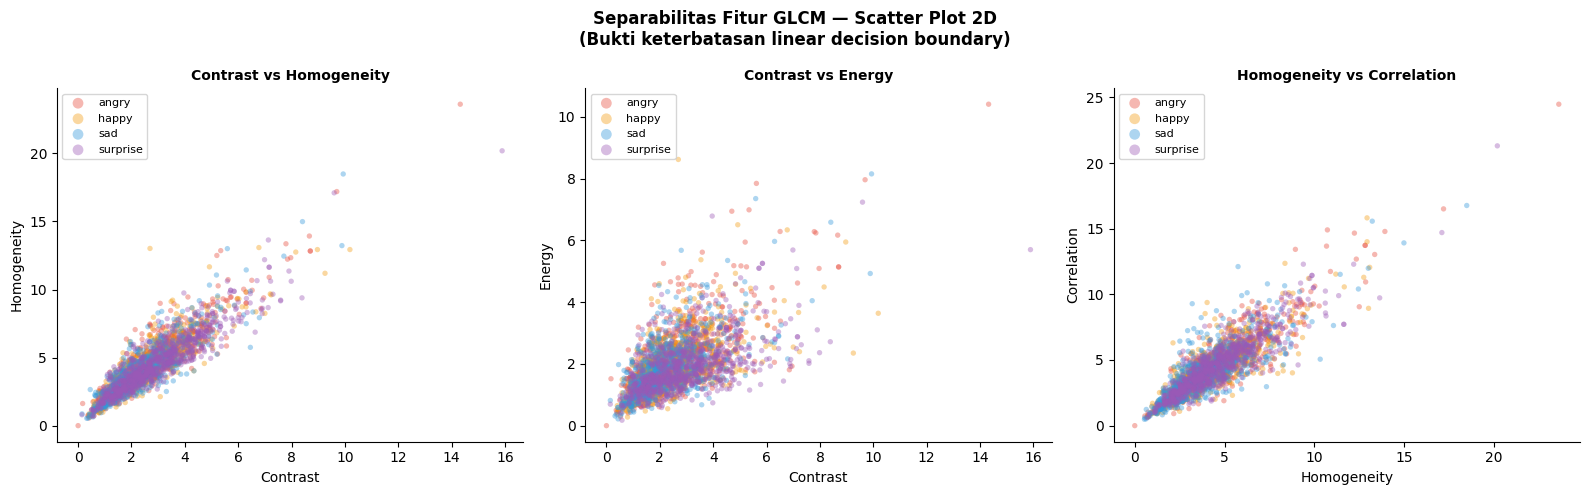


💡 KESIMPULAN KETERBATASAN MODEL LINEAR:

  1. FITUR TIDAK TERPISAH SECARA LINEAR
     Dari scatter plot, terlihat bahwa distribusi fitur GLCM antar kelas
     sangat tumpang tindih. Tidak ada garis lurus yang bisa memisahkan
     keempat kelas dengan baik.

  2. HUBUNGAN FITUR → EMOSI TIDAK LINEAR
     Ekspresi wajah melibatkan kombinasi non-linear antara:
     - Posisi spasial fitur (mana yang di atas vs bawah)
     - Interaksi antar region wajah (mata + mulut bersama)
     - Konteks temporal/3D yang tidak tertangkap gambar 2D

  3. DIMENSI FITUR TERLALU KECIL
     Dengan hanya 4–16 dimensi, LR tidak punya cukup ruang untuk
     membentuk batas keputusan yang memadai.

  4. SOLUSI YANG LEBIH BAIK:
     - CNN yang belajar fitur hierarkis secara end-to-end
     - SVM dengan kernel RBF (non-linear boundary)
     - Gabungan GLCM + LBP + HOG (fitur yang lebih beragam)
     - Dimensi reduksi (PCA) sebelum model


In [23]:
# ── Analisis 4: Keterbatasan Model Linear ─────────────────────
print('=' * 65)
print('ANALISIS 4: Keterbatasan Model Linear (Logistic Regression)')
print('=' * 65)

# Visualisasi 2D scatter fitur GLCM untuk melihat separabilitas
# Gunakan dua fitur yang paling informatif: contrast vs homogeneity
le_best = best_r['le']
X_raw   = best_r['scaler'].inverse_transform(best_r['X_test'])
y_lbl   = np.array(best_r['y_test_lbl'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Separabilitas Fitur GLCM — Scatter Plot 2D\n(Bukti keterbatasan linear decision boundary)',
             fontsize=12, fontweight='bold')

feature_pairs = [
    (0, 1, 'Contrast', 'Homogeneity'),
    (0, 2, 'Contrast', 'Energy'),
    (1, 3, 'Homogeneity', 'Correlation'),
]

for ax, (ix, iy, lx, ly) in zip(axes, feature_pairs):
    for cls in CLASSES:
        mask = y_lbl == cls
        ax.scatter(
            X_raw[mask, ix], X_raw[mask, iy],
            alpha=0.4, s=15, label=cls,
            color=CLASS_COLORS[cls], edgecolors='none'
        )
    ax.set_xlabel(lx, fontsize=10)
    ax.set_ylabel(ly, fontsize=10)
    ax.set_title(f'{lx} vs {ly}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('11_feature_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('''💡 KESIMPULAN KETERBATASAN MODEL LINEAR:

  1. FITUR TIDAK TERPISAH SECARA LINEAR
     Dari scatter plot, terlihat bahwa distribusi fitur GLCM antar kelas
     sangat tumpang tindih. Tidak ada garis lurus yang bisa memisahkan
     keempat kelas dengan baik.

  2. HUBUNGAN FITUR → EMOSI TIDAK LINEAR
     Ekspresi wajah melibatkan kombinasi non-linear antara:
     - Posisi spasial fitur (mana yang di atas vs bawah)
     - Interaksi antar region wajah (mata + mulut bersama)
     - Konteks temporal/3D yang tidak tertangkap gambar 2D

  3. DIMENSI FITUR TERLALU KECIL
     Dengan hanya 4–16 dimensi, LR tidak punya cukup ruang untuk
     membentuk batas keputusan yang memadai.

  4. SOLUSI YANG LEBIH BAIK:
     - CNN yang belajar fitur hierarkis secara end-to-end
     - SVM dengan kernel RBF (non-linear boundary)
     - Gabungan GLCM + LBP + HOG (fitur yang lebih beragam)
     - Dimensi reduksi (PCA) sebelum model''')

ANALISIS 5: Error Analysis — Contoh Gambar Salah Klasifikasi

Total salah klasifikasi: 1961 dari 3100 (63.3%)


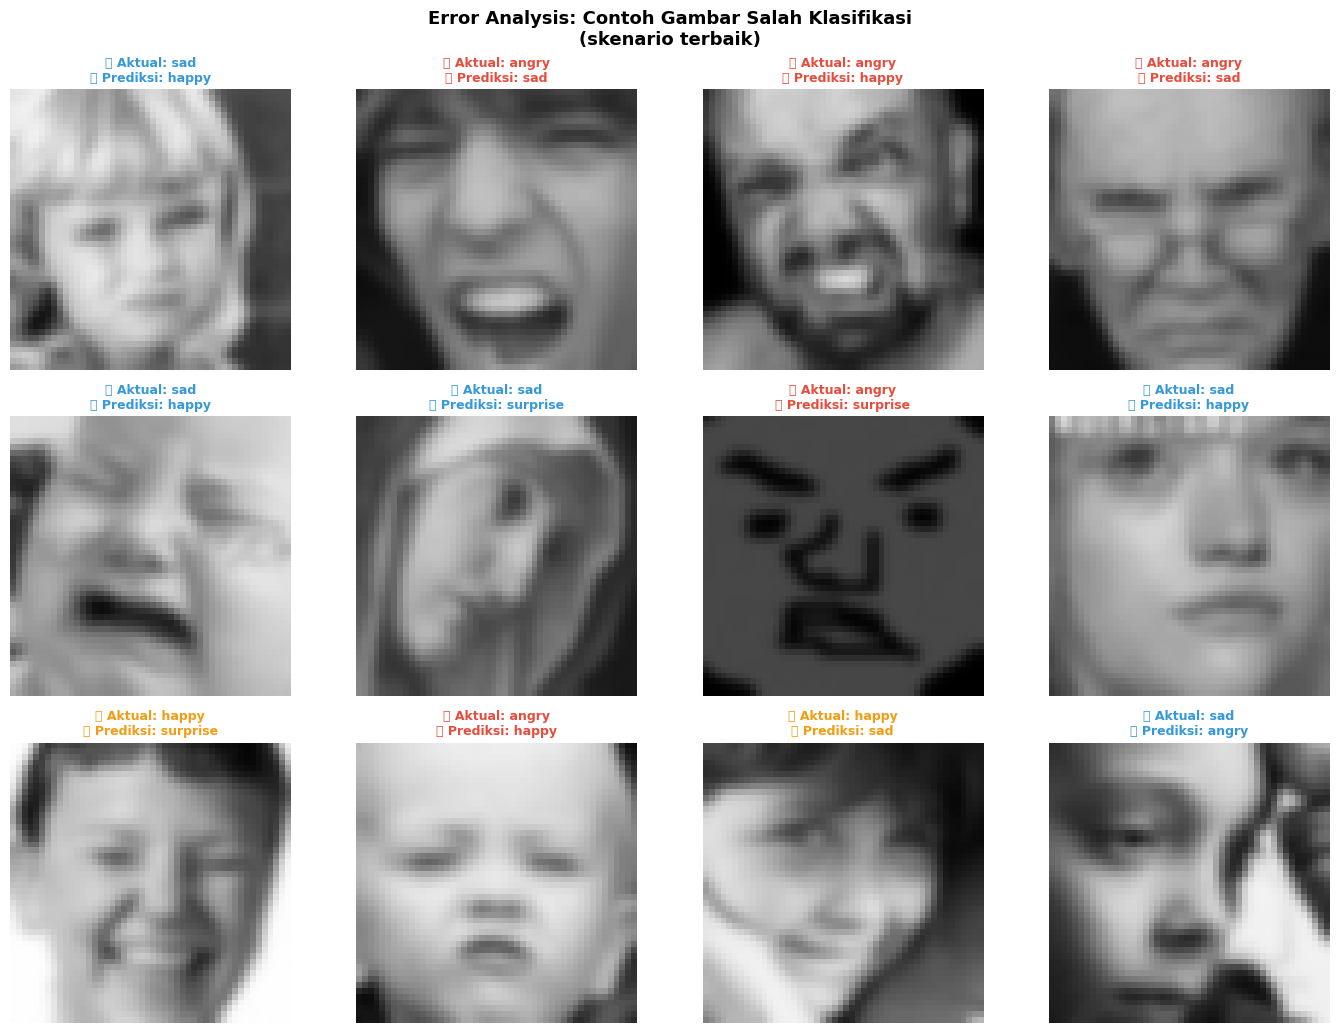


📊 Pasangan kesalahan yang paling sering (true → predicted):
  Aktual → Prediksi                Jumlah   Persentase
  ----------------------------------------------------
  sad → happy                          217       11.1%
  angry → surprise                       216       11.0%
  angry → happy                          197       10.0%
  angry → sad                            188        9.6%
  happy → surprise                       178        9.1%
  happy → sad                            166        8.5%
  sad → surprise                       161        8.2%
  surprise → happy                          143        7.3%
  sad → angry                          133        6.8%
  surprise → angry                          127        6.5%

💡 PENJELASAN POLA KESALAHAN:
  - Kesalahan antar kelas yang "teksturnya mirip" lebih sering terjadi.
  - Contoh: sad dan angry sama-sama cenderung memiliki area dahi gelap
    (alis turun) → GLCM memberikan nilai contrast/homogeneity serupa.
  - Happy yang s

In [24]:
# ── Analisis 5: Error Analysis — Gambar Salah Klasifikasi ────
print('=' * 65)
print('ANALISIS 5: Error Analysis — Contoh Gambar Salah Klasifikasi')
print('=' * 65)

y_true_lbl = np.array(best_r['y_test_lbl'])
y_pred_lbl = np.array(best_r['y_pred_lbl'])
paths_test = np.array(best_r['paths_test'])

# Temukan semua kesalahan
error_mask  = y_true_lbl != y_pred_lbl
n_errors    = error_mask.sum()
print(f'\nTotal salah klasifikasi: {n_errors} dari {len(y_true_lbl)} ({n_errors/len(y_true_lbl)*100:.1f}%)')

# Pilih contoh kesalahan yang representatif (maks 12 gambar)
error_indices  = np.where(error_mask)[0]
np.random.shuffle(error_indices)
selected_errors = error_indices[:12]

n_cols = 4
n_rows = (len(selected_errors) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
fig.suptitle('Error Analysis: Contoh Gambar Salah Klasifikasi\n(skenario terbaik)',
             fontsize=13, fontweight='bold')

axes_flat = axes.ravel() if n_rows > 1 else axes

for ax_idx, err_idx in enumerate(selected_errors):
    ax = axes_flat[ax_idx]

    # Load gambar dari path .npy → convert ke displayable
    npy_path = paths_test[err_idx]
    png_path = npy_path.replace('.npy', '.png')

    try:
        if os.path.exists(png_path):
            img_disp = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
        else:
            img_disp = (np.load(npy_path) * 255).astype(np.uint8)

        true_lbl = y_true_lbl[err_idx]
        pred_lbl = y_pred_lbl[err_idx]

        ax.imshow(img_disp, cmap='gray', vmin=0, vmax=255)
        ax.set_title(
            f'✅ Aktual: {true_lbl}\n❌ Prediksi: {pred_lbl}',
            fontsize=9,
            color=CLASS_COLORS.get(true_lbl, 'black'),
            fontweight='bold'
        )
        ax.axis('off')
        # Border merah untuk error
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor('#E74C3C'); sp.set_linewidth(2)
    except Exception as e:
        ax.text(0.5, 0.5, f'Load error:\n{e}', ha='center', va='center',
                fontsize=8, transform=ax.transAxes)
        ax.axis('off')

# Sembunyikan axes kosong
for ax in axes_flat[len(selected_errors):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('12_error_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# Statistik kesalahan per pasangan kelas
print('\n📊 Pasangan kesalahan yang paling sering (true → predicted):')
from collections import Counter
error_pairs = [(y_true_lbl[i], y_pred_lbl[i]) for i in error_indices]
pair_counts = Counter(error_pairs)
print(f'  {"Aktual → Prediksi":<30} {"Jumlah":>8} {"Persentase":>12}')
print(f'  {"-"*52}')
for (true_c, pred_c), count in pair_counts.most_common(10):
    print(f'  {true_c} → {pred_c:<25} {count:>8} {count/n_errors*100:>10.1f}%')

print()
print('''💡 PENJELASAN POLA KESALAHAN:
  - Kesalahan antar kelas yang "teksturnya mirip" lebih sering terjadi.
  - Contoh: sad dan angry sama-sama cenderung memiliki area dahi gelap
    (alis turun) → GLCM memberikan nilai contrast/homogeneity serupa.
  - Happy yang salah biasanya terjadi pada gambar dengan pencahayaan
    berbeda atau posisi wajah miring.
  - Surprise sering bingung dengan angry karena keduanya bisa memiliki
    mata terbuka lebar (tekstur terang di region mata).''')

---
## 🗺️ 8. Visualisasi Distribusi Fitur GLCM per Kelas

Lihat apakah fitur GLCM membentuk cluster yang terpisah per kelas emosi.

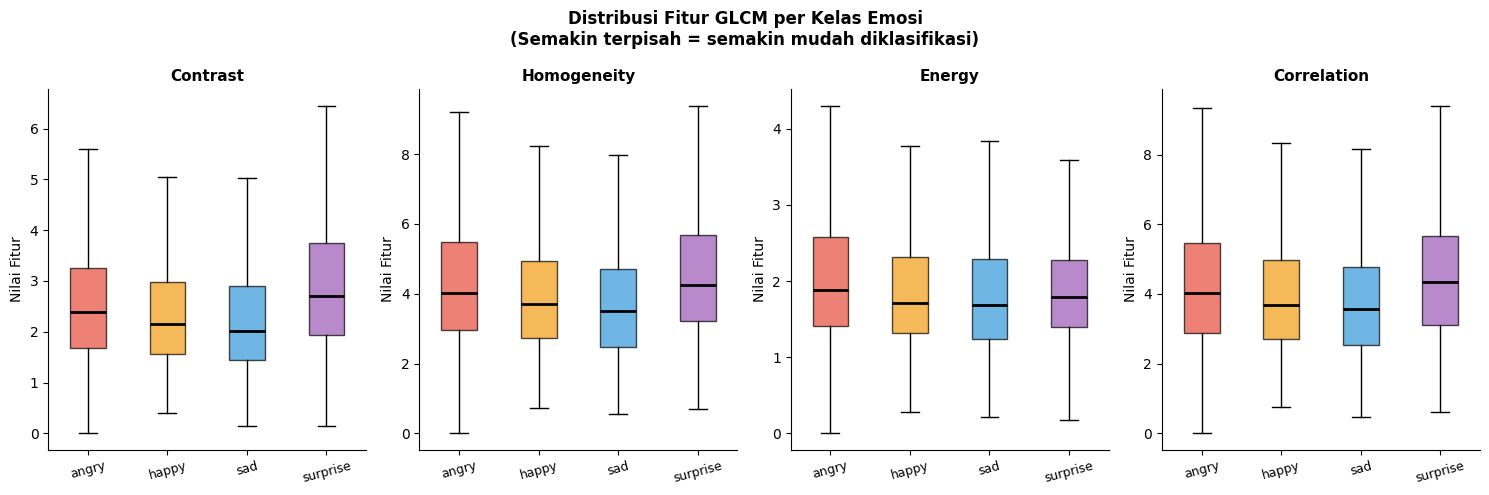

📌 Semakin tinggi tumpang-tindih boxplot antar kelas = semakin sulit dipisahkan.


In [25]:
# ── Boxplot distribusi setiap fitur per kelas ─────────────────
X_raw = best_r['scaler'].inverse_transform(best_r['X_test'])
y_lbl = np.array(best_r['y_test_lbl'])
n_feats = min(4, X_raw.shape[1])  # tampilkan max 4 fitur pertama
feat_names = GLCM_PROPS[:n_feats]

fig, axes = plt.subplots(1, n_feats, figsize=(15, 5))
fig.suptitle('Distribusi Fitur GLCM per Kelas Emosi\n(Semakin terpisah = semakin mudah diklasifikasi)',
             fontsize=12, fontweight='bold')

for fi, (ax, feat_name) in enumerate(zip(axes, feat_names)):
    data_by_class = [X_raw[y_lbl == cls, fi] for cls in CLASSES]
    colors_list   = [CLASS_COLORS[c] for c in CLASSES]

    bp = ax.boxplot(data_by_class, patch_artist=True, showfliers=False,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, len(CLASSES)+1))
    ax.set_xticklabels(CLASSES, rotation=15, fontsize=9)
    ax.set_title(feat_name.capitalize(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai Fitur')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('13_feature_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('📌 Semakin tinggi tumpang-tindih boxplot antar kelas = semakin sulit dipisahkan.')

In [26]:
# ── Eksperimen Wajib 1: GLCM level=16 vs level=32 (bar chart) ─
print('EKSPERIMEN WAJIB 1: Perbandingan Level Kuantisasi')
print('='*55)

level_results = {}
for r in results:
    lv = r['levels']
    if lv not in level_results:
        level_results[lv] = []
    level_results[lv].append(r['accuracy'])

print(f'\n  {"Level":<8} {"Mean Accuracy":>15} {"Std":>10}')
print(f'  {"-"*35}')
for lv, accs in sorted(level_results.items()):
    print(f'  {lv:<8} {np.mean(accs):>15.4f} {np.std(accs):>10.4f}')

print('\n→ Kesimpulan: Level yang lebih tinggi (32) memberikan resolusi tekstur lebih detail,')
print('  namun perbedaan akurasi biasanya marginal (<1–2%) karena bottleneck ada pada')
print('  ketidakmampuan GLCM menangkap struktur spasial wajah.')

print('\nEKSPERIMEN WAJIB 2: Perbandingan Agregasi (mean vs concat)')
print('='*55)

agg_results = {}
for r in results:
    agg = r['aggregation']
    if agg not in agg_results:
        agg_results[agg] = []
    agg_results[agg].append(r['accuracy'])

print(f'\n  {"Agregasi":<10} {"Feat Dim":<10} {"Mean Accuracy":>15}')
print(f'  {"-"*37}')
agg_dim = {'mean': 4, 'concat': 16}
for agg, accs in agg_results.items():
    print(f'  {agg:<10} {agg_dim[agg]:<10} {np.mean(accs):>15.4f}')

winner_agg = max(agg_results, key=lambda k: np.mean(agg_results[k]))
print(f'\n→ Agregasi {winner_agg.upper()} memberikan akurasi lebih baik.')
if winner_agg == 'concat':
    print('  Concatenation mempertahankan informasi arah tekstur per sudut,')
    print('  memberikan lebih banyak informasi dibanding rata-rata yang menghilangkan variasi antar sudut.')
else:
    print('  Mean aggregation mengurangi noise dan menghasilkan fitur yang lebih stabil,')
    print('  meskipun kehilangan informasi arah tekstur individual per sudut.')

EKSPERIMEN WAJIB 1: Perbandingan Level Kuantisasi

  Level      Mean Accuracy        Std
  -----------------------------------
  16                0.3450     0.0208
  32                0.3479     0.0195

→ Kesimpulan: Level yang lebih tinggi (32) memberikan resolusi tekstur lebih detail,
  namun perbedaan akurasi biasanya marginal (<1–2%) karena bottleneck ada pada
  ketidakmampuan GLCM menangkap struktur spasial wajah.

EKSPERIMEN WAJIB 2: Perbandingan Agregasi (mean vs concat)

  Agregasi   Feat Dim     Mean Accuracy
  -------------------------------------
  mean       4                   0.3263
  concat     16                  0.3666

→ Agregasi CONCAT memberikan akurasi lebih baik.
  Concatenation mempertahankan informasi arah tekstur per sudut,
  memberikan lebih banyak informasi dibanding rata-rata yang menghilangkan variasi antar sudut.


---
## 📝 9. Ringkasan & Kesimpulan

In [27]:
# ── Tabel Ringkasan Pipeline ──────────────────────────────────
print('RINGKASAN PIPELINE PREPROCESSING')
print('='*75)

pipeline_table = pd.DataFrame([
    {'Langkah': '1. Load',          'Proses': 'cv2.imread',           'Input': 'File JPG/PNG',      'Output': 'Array BGR',         'Catatan': 'Baca dari disk'},
    {'Langkah': '2. Grayscale',     'Proses': 'COLOR_BGR2GRAY',       'Input': 'BGR (3ch)',          'Output': '(48,48) uint8',     'Catatan': 'Otomatis jika diperlukan'},
    {'Langkah': '3. Resize',        'Proses': 'cv2.resize',           'Input': 'Ukuran bervariasi', 'Output': '(48,48) uint8',     'Catatan': 'INTER_LINEAR'},
    {'Langkah': '4. Gaussian',      'Proses': 'gaussian_filter',      'Input': '(48,48) uint8',     'Output': '(48,48) uint8',     'Catatan': 'σ=1.0'},
    {'Langkah': '5. Normalisasi',   'Proses': '/ 255.0',              'Input': 'uint8 [0,255]',     'Output': 'float32 [0,1]',     'Catatan': 'Untuk GLCM'},
    {'Langkah': '6. Kuantisasi',    'Proses': '× (L-1)',              'Input': 'float32 [0,1]',     'Output': f'uint8 [0,L-1]',    'Catatan': 'L=16 atau 32'},
    {'Langkah': '7. GLCM',         'Proses': 'graycomatrix',          'Input': 'uint8 [0,L-1]',     'Output': f'Matrix L×L×1×4',   'Catatan': 'd=1, 4 sudut'},
    {'Langkah': '8. Ekstraksi',     'Proses': 'graycoprops',          'Input': 'Matrix GLCM',       'Output': '4 atau 16 fitur',   'Catatan': 'contrast/homogen/energy/corr'},
    {'Langkah': '9. LR',           'Proses': 'LogisticRegression',    'Input': 'Fitur vektor',      'Output': 'Label emosi',       'Catatan': 'max_iter=1000'},
])

print(pipeline_table.to_string(index=False))

print('\n')
print('HASIL EKSPERIMEN')
print('='*75)
print(df_results.to_string(index=False))

print('\n')
print('KESIMPULAN UTAMA')
print('='*75)
best_r = results[best_idx]
print(f'''
1. AKURASI TERBAIK: {best_r['accuracy']*100:.2f}% (Skenario {best_r['scenario']})
   Ini jauh di bawah kemampuan manusia (~65%) dan CNN (~65–70%),
   mengkonfirmasi keterbatasan fitur tekstur GLCM.

2. GLCM TIDAK CUKUP untuk klasifikasi emosi wajah.
   Fitur tekstur global tidak mampu menangkap geometri ekspresi wajah.

3. LOGISTIC REGRESSION (LINEAR) tidak memadai.
   Distribusi fitur GLCM antar kelas tidak linearly separable.

4. REKOMENDASI:
   - Gunakan CNN (ResNet/EfficientNet) untuk ekstraksi fitur otomatis
   - Kombinasikan GLCM + LBP + HOG untuk representasi yang lebih kaya
   - Gunakan SVM dengan kernel RBF sebagai model yang lebih powerful
   - Pertimbangkan Face Alignment sebelum ekstraksi fitur
''')

RINGKASAN PIPELINE PREPROCESSING
       Langkah             Proses             Input          Output                      Catatan
       1. Load         cv2.imread      File JPG/PNG       Array BGR               Baca dari disk
  2. Grayscale     COLOR_BGR2GRAY         BGR (3ch)   (48,48) uint8     Otomatis jika diperlukan
     3. Resize         cv2.resize Ukuran bervariasi   (48,48) uint8                 INTER_LINEAR
   4. Gaussian    gaussian_filter     (48,48) uint8   (48,48) uint8                        σ=1.0
5. Normalisasi            / 255.0     uint8 [0,255]   float32 [0,1]                   Untuk GLCM
 6. Kuantisasi            × (L-1)     float32 [0,1]   uint8 [0,L-1]                 L=16 atau 32
       7. GLCM       graycomatrix     uint8 [0,L-1]  Matrix L×L×1×4                 d=1, 4 sudut
  8. Ekstraksi        graycoprops       Matrix GLCM 4 atau 16 fitur contrast/homogen/energy/corr
         9. LR LogisticRegression      Fitur vektor     Label emosi                max_iter=10

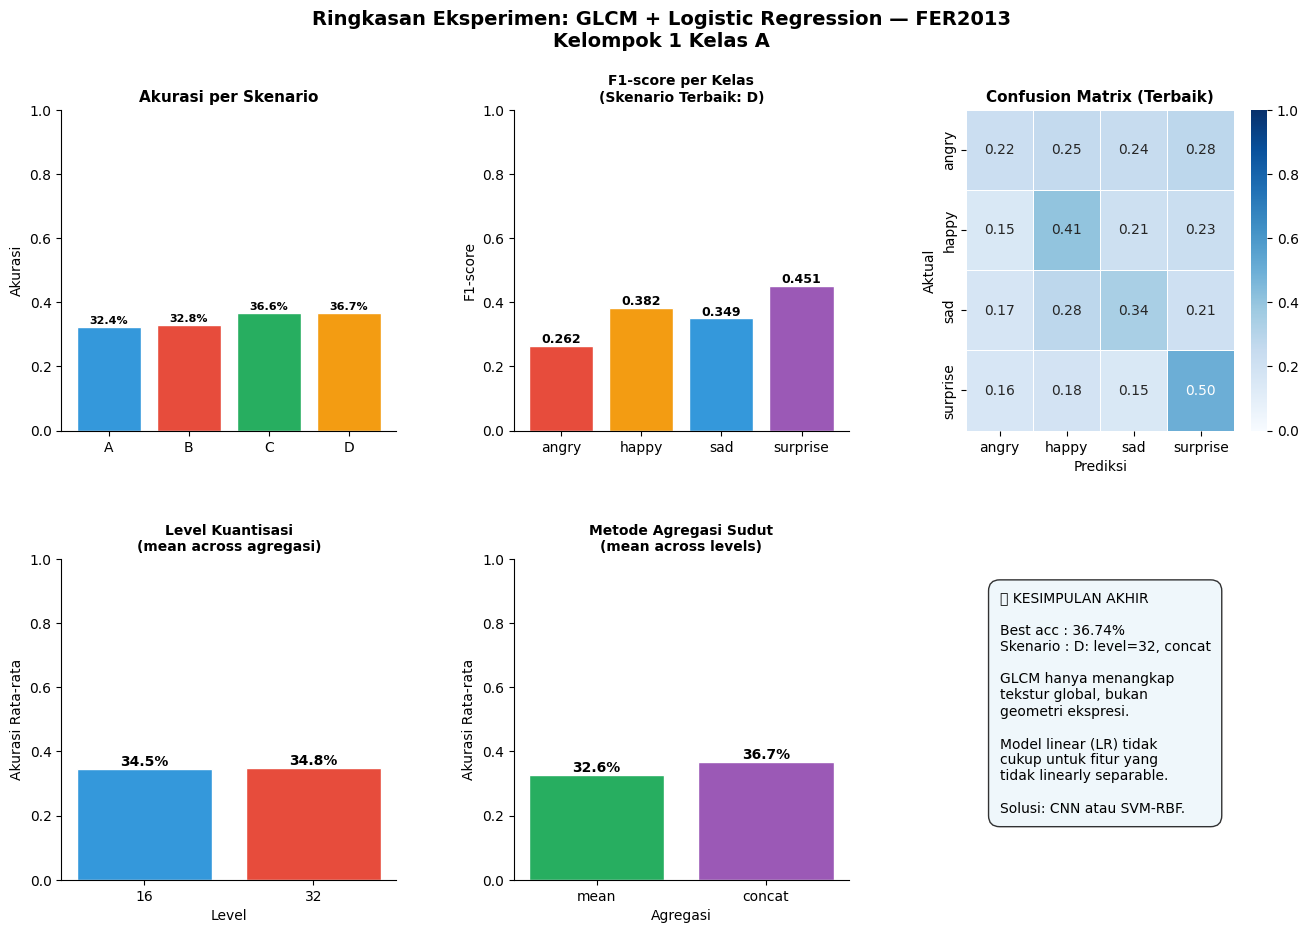

✅ Semua visualisasi dan analisis selesai!


In [28]:
# ── Visualisasi Ringkasan Akhir ───────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

fig.suptitle('Ringkasan Eksperimen: GLCM + Logistic Regression — FER2013\nKelompok 1 Kelas A',
             fontsize=14, fontweight='bold')

# (a) Akurasi semua skenario
ax1 = fig.add_subplot(gs[0, 0])
sc_names = [r['scenario'].split(':')[0].strip() for r in results]
accs     = [r['accuracy'] for r in results]
bars     = ax1.bar(sc_names, accs, color=colors_sc, edgecolor='white')
ax1.set_title('Akurasi per Skenario', fontsize=11, fontweight='bold')
ax1.set_ylabel('Akurasi')
ax1.set_ylim(0, 1.0)
ax1.spines[['top','right']].set_visible(False)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc*100:.1f}%', ha='center', fontsize=8, fontweight='bold')

# (b) F1 skenario terbaik
ax2 = fig.add_subplot(gs[0, 1])
f1s  = {cls: best_r['report'][cls]['f1-score'] for cls in CLASSES}
clrs = [CLASS_COLORS[c] for c in CLASSES]
bars2 = ax2.bar(CLASSES, list(f1s.values()), color=clrs, edgecolor='white')
ax2.set_title(f'F1-score per Kelas\n(Skenario Terbaik: {best_r["scenario"].split(":")[0]})',
              fontsize=10, fontweight='bold')
ax2.set_ylabel('F1-score')
ax2.set_ylim(0, 1.0)
ax2.spines[['top','right']].set_visible(False)
for bar, (cls, f1) in zip(bars2, f1s.items()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{f1:.3f}', ha='center', fontsize=9, fontweight='bold')

# (c) Confusion matrix skenario terbaik
ax3 = fig.add_subplot(gs[0, 2])
cm_best = confusion_matrix(best_r['y_test'], best_r['y_pred'])
cm_norm = cm_best.astype('float') / cm_best.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=best_r['le'].classes_,
            yticklabels=best_r['le'].classes_,
            ax=ax3, vmin=0, vmax=1, linewidths=0.5)
ax3.set_title('Confusion Matrix (Terbaik)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Prediksi'); ax3.set_ylabel('Aktual')

# (d) Level kuantisasi comparison
ax4 = fig.add_subplot(gs[1, 0])
lv_data   = {lv: np.mean(accs) for lv, accs in level_results.items()}
bars4     = ax4.bar([str(k) for k in sorted(lv_data)],
                     [lv_data[k] for k in sorted(lv_data)],
                     color=['#3498DB', '#E74C3C'], edgecolor='white')
ax4.set_title('Level Kuantisasi\n(mean across agregasi)', fontsize=10, fontweight='bold')
ax4.set_xlabel('Level'); ax4.set_ylabel('Akurasi Rata-rata')
ax4.set_ylim(0, 1.0)
ax4.spines[['top','right']].set_visible(False)
for bar, (lv, acc) in zip(bars4, sorted(lv_data.items())):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

# (e) Agregasi comparison
ax5 = fig.add_subplot(gs[1, 1])
agg_data = {agg: np.mean(accs) for agg, accs in agg_results.items()}
bars5    = ax5.bar(list(agg_data.keys()), list(agg_data.values()),
                    color=['#27AE60', '#9B59B6'], edgecolor='white')
ax5.set_title('Metode Agregasi Sudut\n(mean across levels)', fontsize=10, fontweight='bold')
ax5.set_xlabel('Agregasi'); ax5.set_ylabel('Akurasi Rata-rata')
ax5.set_ylim(0, 1.0)
ax5.spines[['top','right']].set_visible(False)
for bar, (agg, acc) in zip(bars5, agg_data.items()):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

# (f) Teks kesimpulan
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_text = (
    f"📌 KESIMPULAN AKHIR\n\n"
    f"Best acc : {best_r['accuracy']*100:.2f}%\n"
    f"Skenario : {best_r['scenario']}\n\n"
    f"GLCM hanya menangkap\ntekstur global, bukan\ngeometri ekspresi.\n\n"
    f"Model linear (LR) tidak\ncukup untuk fitur yang\ntidak linearly separable.\n\n"
    f"Solusi: CNN atau SVM-RBF."
)
ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes,
          fontsize=10, verticalalignment='top',
          bbox=dict(boxstyle='round,pad=0.8', facecolor='#EBF5FB', alpha=0.8))

plt.savefig('14_ringkasan_akhir.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Semua visualisasi dan analisis selesai!')

---
## 📁 Daftar Output File

| File | Isi |
|------|-----|
| `01_distribusi_kelas.png` | Bar chart distribusi kelas train/test |
| `02_sampel_raw.png` | Contoh gambar RAW per kelas |
| `03_gaussian_comparison.png` | Perbandingan sigma Gaussian filter |
| `04_normalisasi.png` | Demonstrasi normalisasi piksel |
| `05_verifikasi_stepbystep.png` | Semua langkah preprocessing per kelas |
| `06_glcm_matrix_viz.png` | Visualisasi GLCM matrix 4 sudut |
| `07_perbandingan_skenario.png` | Akurasi & F1 semua skenario |
| `08_confusion_matrix_all.png` | Confusion matrix 4 skenario |
| `09_f1_heatmap.png` | Heatmap F1 skenario × kelas |
| `10_glcm_level_comparison.png` | Pengaruh level kuantisasi GLCM |
| `11_feature_scatter.png` | Scatter plot fitur 2D (separabilitas) |
| `12_error_analysis.png` | Gambar-gambar salah klasifikasi |
| `13_feature_distribution.png` | Boxplot distribusi fitur per kelas |
| `14_ringkasan_akhir.png` | Dashboard ringkasan eksperimen |
| `fer2013_preprocessed/` | Seluruh gambar hasil preprocessing |

---
*Tugas Kelompok 1 Kelas A — Klasifikasi Emosi Wajah (GLCM + Logistic Regression)*